[PLANT] Using T=25.0°C: R_s=2.3000, R_r=2.5000
[PLANT] Saturation case=vstrong: L_m=0.1200
[CTRL ] Rated params: R_s=2.3000, R_r=2.5000, L_m=0.2400
=== Dynamic Quantum Lyapunov Synthesis for IM Drive ===

=== Decision step 1/11 at t=0.0000s ===
   Updated parameter ranges after BH:
      k_psi: [5125.271, 5148.181] (width=22.910)
      k_w: [6047.031, 6069.018] (width=21.987)
      theta_psi: [844.001, 862.602] (width=18.601)
      theta_w: [177.379, 191.533] (width=14.154)
   Selected params: s=000011100000, k_psi=5125.271, k_w=6056.454, theta_psi=854.630, theta_w=177.379, E=1.246558, J=1.246586
   solver = bruteforce, num_qubits = 12, H-fit time = 31.364375 s, QUBO solve time = 1.480838 s
   State at end of interval: [-3.95976358 -6.45740404 -0.58125216 -0.68484915 99.90524586]
   Tracking error norm = 1.310e-01

=== Decision step 2/11 at t=0.2000s ===
   Updated parameter ranges after BH:
      k_psi: [5130.664, 5147.484] (width=16.821)
      k_w: [6051.238, 6067.758] (width=16.520)

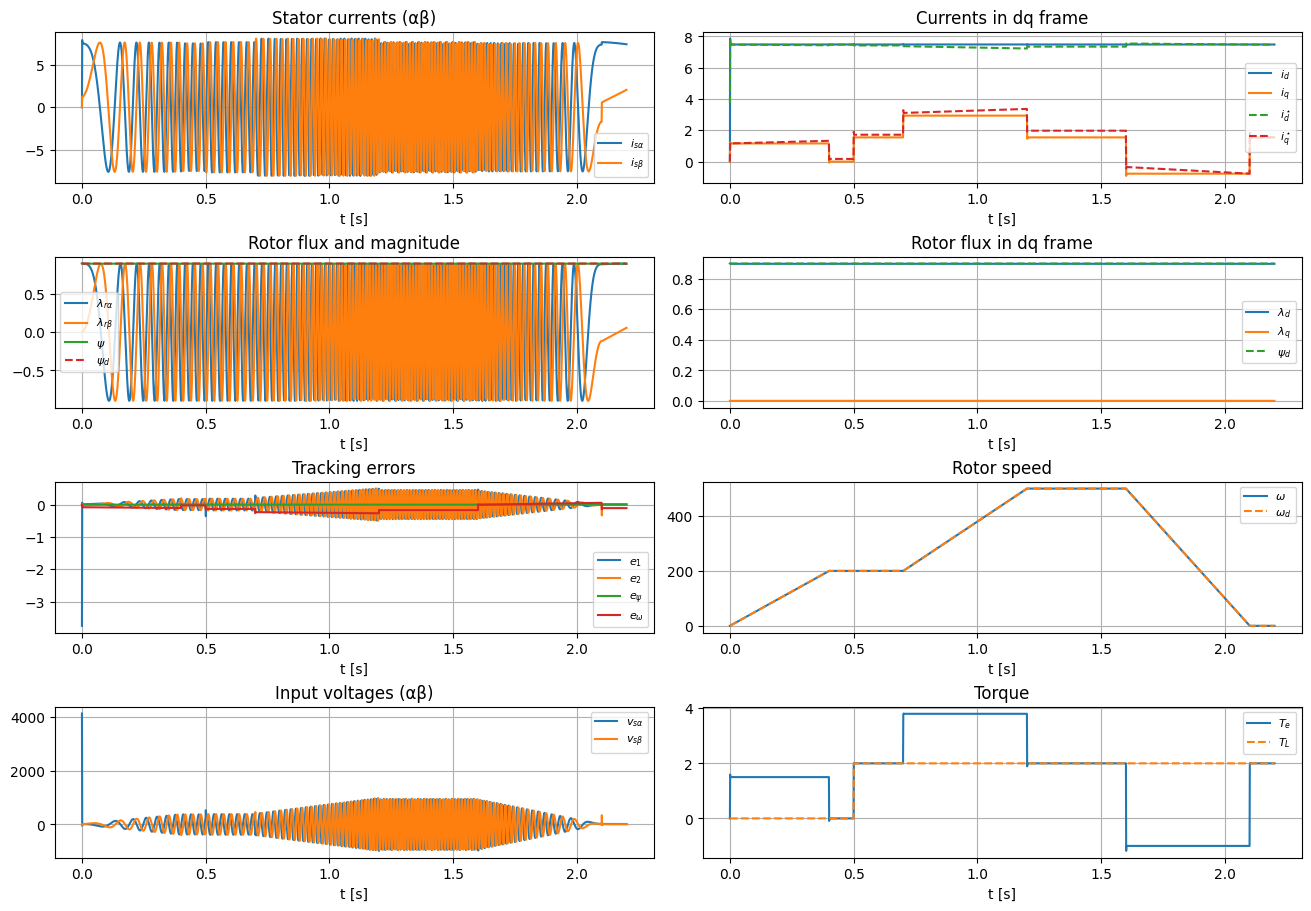

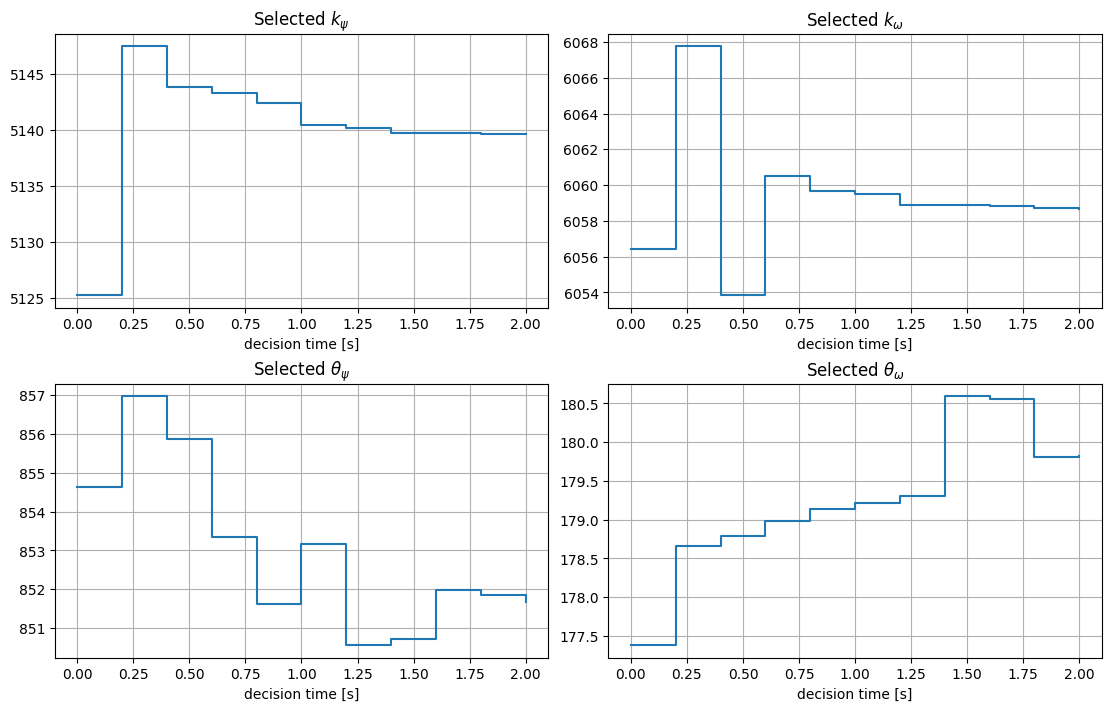

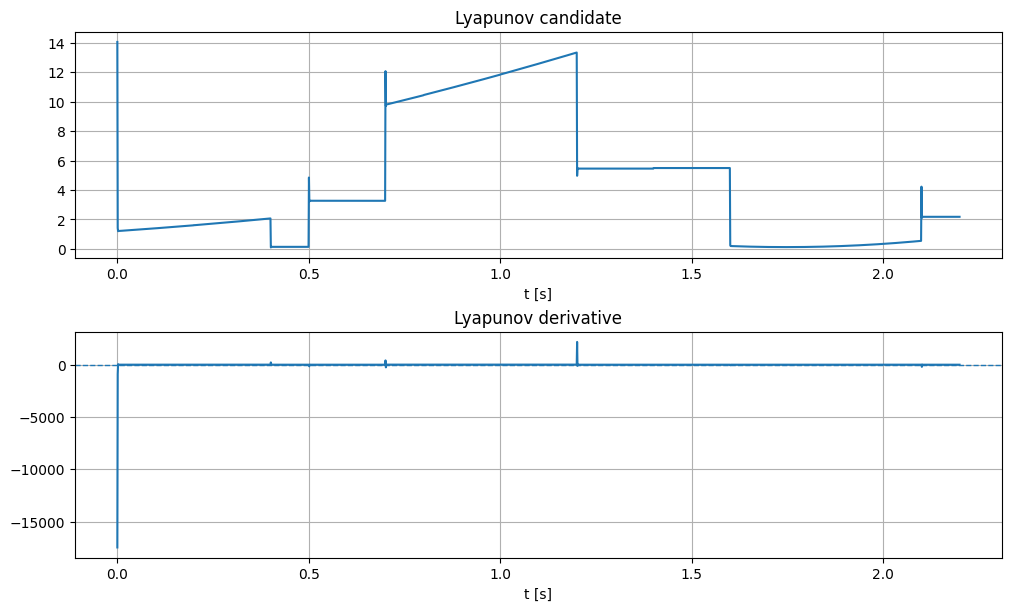


Final state at t = 2.2000s
  i_sα = 7.369980e+00
  i_sβ = 2.026413e+00
  λ_rα = 8.963813e-01
  λ_rβ = 5.801239e-02
  ω    = -1.100216e-01

Final tracking error norm:
  ||e|| = 1.104094e-01

Final parameter ranges after last BH:
  k_psi: [5139.321, 5139.619]
  k_w: [6058.558, 6058.681]
  theta_psi: [851.216, 851.662]
  theta_w: [179.824, 180.132]

Selected online parameters by epoch:
  step 01: solver=bruteforce, nq=12, Hfit=31.364375s, solve=1.480838s, E=1.246558, J=1.246586, k_psi=5125.271, k_w=6056.454, theta_psi=854.630, theta_w=177.379, s=000011100000
  step 02: solver=bruteforce, nq=12, Hfit=57.815834s, solve=1.372880s, E=1.092503, J=1.092258, k_psi=5147.484, k_w=6067.758, theta_psi=856.966, theta_w=178.662, s=111111101000
  step 03: solver=bruteforce, nq=12, Hfit=66.962574s, solve=1.490266s, E=15672.507854, J=15671.822885, k_psi=5143.869, k_w=6053.840, theta_psi=855.871, theta_w=178.793, s=111000101000
  step 04: solver=bruteforce, nq=12, Hfit=70.706278s, solve=1.293749s, E=3558

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

from qiskit.quantum_info import SparsePauliOp, Statevector
from qiskit.primitives import Estimator
from qiskit.circuit.library import EfficientSU2
from qiskit_algorithms import VarQITE
from qiskit_algorithms.time_evolvers import TimeEvolutionProblem
from qiskit_algorithms.time_evolvers.variational import ImaginaryMcLachlanPrinciple
import time
from itertools import product


# ============================================================
# GLOBAL CONFIGURATION
# ============================================================

VERBOSE = False

# ============================================================
# IM DRIVE BASE DATA
# ============================================================

# ---- 3-phase supply settings (used only when mode="threephase") ----
V_phase_rms = 80.0
f_e = 60.0
phase_offset = 0.0

# ---- Motor base parameters ----
L_s = 0.25
L_r = 0.25
p_p = 2
J = 0.003

# ---- Rated parameters used INSIDE controller (fixed model) ----
R_s_ctl = 2.3
R_r_ctl = 2.5
L_m_ctl = 0.24

# ---- Actual plant parameters (mismatch scenario) ----
T_ref = 25.0
alpha_Cu = 0.00393

R_s_ref = 2.3
R_r_ref = 2.5

T_C = 25.0
R_s = R_s_ref * (1.0 + alpha_Cu * (T_C - T_ref))
R_r = R_r_ref * (1.0 + alpha_Cu * (T_C - T_ref))

Lm_nom = 0.24
sat_case = "vstrong"   # "none", "mild", "strong"

if sat_case == "none":
    L_m = Lm_nom
elif sat_case == "mild":
    L_m = 0.90 * Lm_nom
elif sat_case == "strong":
    L_m = 0.75 * Lm_nom
elif sat_case == "vstrong":
    L_m = 0.5 * Lm_nom   # 50% drop
else:
    raise ValueError("Unknown sat_case")

print(f"[PLANT] Using T={T_C}°C: R_s={R_s:.4f}, R_r={R_r:.4f}")
print(f"[PLANT] Saturation case={sat_case}: L_m={L_m:.4f}")
print(f"[CTRL ] Rated params: R_s={R_s_ctl:.4f}, R_r={R_r_ctl:.4f}, L_m={L_m_ctl:.4f}")

# ---- Initial condition: x = [i_sα, i_sβ, λ_rα, λ_rβ, ω] ----
psi_const = 0.9
X0_GLOBAL = np.array([0.0, 0.0, psi_const, 0.0, 0.0], dtype=float)

psi_floor = 1e-3
np.random.seed(0)
# ============================================================
# ONLINE FRAMEWORK SETTINGS
# ============================================================

# Parameters to optimize online:
# p = [k_psi, k_w, theta_psi, theta_w]
PARAM_NAMES = ["k_psi", "k_w", "theta_psi", "theta_w"]

# Search box
P_MIN_GLOBAL = np.array([1.0,   1.0,   0.1,  0.1], dtype=float)
P_MAX_GLOBAL = np.array([10000.0, 10000.0, 2000.0, 2000.0], dtype=float)

# Stage 1: Black Hole
BH_POP_SIZE = 20
BH_MAX_ITERS = 100
BH_FREEZE_WIDTH = 25.0

# Online decision loop
T_TOTAL = 2.2
DT_DECISION = 0.2

# Horizon cost
T_HORIZON_COST = 0.10
N_TIME_COST = 120

# Cost weights
W_EPSI = 2.0
W_EW   = 10.0
W_EI   = 10.0
W_U    = 1e-4
W_LYAP = 1.0

QUBO_SOLVER = "bruteforce"     # "qite", "bruteforce", "classic"
CLASSIC_SOLVER = "sa"    # for now: "sa" = simulated annealing style local search

# QITE
QITE_TAU = 2.0
QITE_STEPS = 60
QITE_REPS = 2
QITE_SEED_BASE = 42

# Classical local-search settings
CLASSIC_NUM_RESTARTS = 20
CLASSIC_MAX_FLIPS = 200
CLASSIC_SEED_BASE = 123

# Hamiltonian fit sampling
TRAIN_SAMPLE_FACTOR = 4
MIN_TRAIN_SAMPLES = 64
TOP_K_CANDIDATES = 32

# Bit allocation
BIT_WIDTH_THRESHOLDS = [5.0, 20.0]
BIT_ALLOCATION = [2, 3, 4]
MAX_BITS_PER_PARAM = 4

# ============================================================
# REFERENCE / LOAD SETTINGS
# ============================================================

mode = "controller"   # "controller" or "threephase"

# ---- Speed reference ----
w_type = "profile"  # "step","ramp","sine","profile","custom"

w_step = 200.0
w_ramp_t0 = 0.1
w_ramp_t1 = 0.8
w_ramp_slope = 250.0

w_sine_amp = 50.0
w_sine_bias = 150.0
w_sine_freq_hz = 1.0

w_profile = (
    (0.0, 0.4, 0.0, 200.0),
    (0.4, 0.7, 200.0, 200.0),
    (0.7, 1.2, 200.0, 500.0),
    (1.2, 1.6, 500.0, 500.0),
    (1.6, 2.1, 500.0, 0.0),
)

def w_custom(t: float):
    w = 100.0 + 50.0*np.sin(2*np.pi*0.5*t)
    dw = 50.0*(2*np.pi*0.5)*np.cos(2*np.pi*0.5*t)
    ddw = -50.0*(2*np.pi*0.5)**2*np.sin(2*np.pi*0.5*t)
    return w, dw, ddw

# ---- Flux reference ----
psi_type = "constant"  # "constant","step","ramp","sine","custom"
psi_step_t0 = 0.1
psi_step = 0.9

psi_ramp_t0 = 0.1
psi_ramp_t1 = 0.8
psi_ramp_slope = 0.2

psi_sine_amp = 0.1
psi_sine_bias = 0.8
psi_sine_freq_hz = 0.5

def psi_custom(t: float):
    psi = 0.9
    return psi, 0.0, 0.0

# ---- Load torque ----
TL_type = "step"  # "constant","step","sine","custom"
TL_const = 1.0

TL_step_t0 = 0.5
TL_step = 2.0

TL_sine_amp = 0.5
TL_sine_bias = 1.0
TL_sine_freq_hz = 1.0

def TL_custom(t: float):
    TL = 1.0
    return TL, 0.0

# ============================================================
# MOTOR COEFFICIENTS
# ============================================================

def motor_coeffs(Rs, Rr, Lm, Ls, Lr, p_p, J):
    L_sigma = Ls * (1.0 - (Lm**2) / (Ls * Lr))

    a_s = Rs / L_sigma + (Rr * Lm**2) / (Lr**2 * L_sigma)
    b_s = (Rr * Lm) / (Lr**2 * L_sigma)
    c_s = Lm / (L_sigma * Lr)

    alpha = (Rr * Lm) / Lr
    beta  = - Rr / Lr
    gamma = (3.0/2.0) * (p_p / J) * (Lm / Lr)

    return L_sigma, a_s, b_s, c_s, alpha, beta, gamma

# Plant coefficients
L_sigma_p, a_s_p, b_s_p, c_s_p, alpha_p, beta_p, gamma_p = motor_coeffs(
    R_s, R_r, L_m, L_s, L_r, p_p, J
)

# Controller nominal coefficients
L_sigma_c, a_s_c, b_s_c, c_s_c, alpha_c, beta_c, gamma_c = motor_coeffs(
    R_s_ctl, R_r_ctl, L_m_ctl, L_s, L_r, p_p, J
)

# ============================================================
# REFERENCES / LOAD
# ============================================================

def ref_step_fn(t: float, t_sw: float, value: float, bias: float = 0.0):
    r = bias + (value if t >= t_sw else 0.0)
    return r, 0.0, 0.0

def ref_ramp_fn(t: float, t0: float, t1: float, slope: float, bias: float = 0.0):
    if t < t0:
        return bias, 0.0, 0.0
    if t < t1:
        r = bias + slope*(t - t0)
        return r, slope, 0.0
    r = bias + slope*(t1 - t0)
    return r, 0.0, 0.0

def ref_sine_fn(t: float, amp: float, bias: float, freq_hz: float):
    w = 2.0*np.pi*freq_hz
    r = bias + amp*np.sin(w*t)
    dr = amp*w*np.cos(w*t)
    ddr = -amp*(w**2)*np.sin(w*t)
    return r, dr, ddr

def ref_piecewise_linear_fn(t: float, segments):
    t0_first, t1_first, y0_first, y1_first = segments[0]
    if t <= t0_first:
        return y0_first, 0.0, 0.0

    for (t0_, t1_, y0_, y1_) in segments:
        if t0_ <= t <= t1_:
            if abs(t1_ - t0_) < 1e-12:
                return y1_, 0.0, 0.0
            slope = (y1_ - y0_) / (t1_ - t0_)
            y = y0_ + slope*(t - t0_)
            return y, slope, 0.0

    return segments[-1][3], 0.0, 0.0

def speed_reference(t: float):
    if w_type == "step":
        return ref_step_fn(t, 0.0, w_step, 0.0)
    if w_type == "ramp":
        return ref_ramp_fn(t, w_ramp_t0, w_ramp_t1, w_ramp_slope, 0.0)
    if w_type == "sine":
        return ref_sine_fn(t, w_sine_amp, w_sine_bias, w_sine_freq_hz)
    if w_type == "profile":
        return ref_piecewise_linear_fn(t, w_profile)
    if w_type == "custom":
        return w_custom(t)
    raise ValueError(f"Unknown w_type: {w_type}")

def flux_reference(t: float):
    if psi_type == "constant":
        return psi_const, 0.0, 0.0
    if psi_type == "step":
        return ref_step_fn(t, psi_step_t0, psi_step, 0.0)
    if psi_type == "ramp":
        return ref_ramp_fn(t, psi_ramp_t0, psi_ramp_t1, psi_ramp_slope, 0.0)
    if psi_type == "sine":
        return ref_sine_fn(t, psi_sine_amp, psi_sine_bias, psi_sine_freq_hz)
    if psi_type == "custom":
        return psi_custom(t)
    raise ValueError(f"Unknown psi_type: {psi_type}")

def load_torque(t: float):
    if TL_type == "constant":
        return TL_const, 0.0
    if TL_type == "step":
        TL = TL_step if t >= TL_step_t0 else 0.0
        return TL, 0.0
    if TL_type == "sine":
        w_ = 2.0*np.pi*TL_sine_freq_hz
        TL = TL_sine_bias + TL_sine_amp*np.sin(w_*t)
        dTL = TL_sine_amp*w_*np.cos(w_*t)
        return TL, dTL
    if TL_type == "custom":
        return TL_custom(t)
    raise ValueError(f"Unknown TL_type: {TL_type}")

def three_phase_voltages(t: float, V_phase_rms: float, f_e: float, phase_offset: float = 0.0):
    w_ = 2.0 * np.pi * f_e
    Vp = np.sqrt(2.0) * V_phase_rms
    va = Vp * np.sin(w_*t + phase_offset)
    vb = Vp * np.sin(w_*t + phase_offset - 2.0*np.pi/3.0)
    vc = Vp * np.sin(w_*t + phase_offset + 2.0*np.pi/3.0)
    return va, vb, vc

def abc_to_alphabeta(va: float, vb: float, vc: float):
    v_alpha = (2.0/3.0) * (va - 0.5*vb - 0.5*vc)
    v_beta  = (2.0/3.0) * (np.sqrt(3.0)/2.0) * (vb - vc)
    return v_alpha, v_beta

def supply_u_alphabeta(t: float):
    va, vb, vc = three_phase_voltages(t, V_phase_rms, f_e, phase_offset)
    return abc_to_alphabeta(va, vb, vc)

def evaluate_true_cost_from_bitstring_im(bitstr, x0, t_start_abs, p_min, p_max, bits_per_param):
    k_psi, k_w, theta_psi, theta_w = decode_bitstring_to_params(
        bitstr, p_min, p_max, bits_per_param
    )
    J = simulate_horizon_cost_im(
        x0, k_psi, k_w, theta_psi, theta_w,
        t_start_abs=t_start_abs
    )
    return J

def brute_force_select_best_bitstring_on_H(H, num_qubits):
    best_s = None
    best_E = float("inf")

    for bits in product("01", repeat=num_qubits):
        s = "".join(bits)
        E = diagonal_hamiltonian_energy_of_bitstring(H, s)
        if E < best_E:
            best_s = s
            best_E = E

    return best_s, best_E

def random_bitstring(n, rng):
    return "".join(rng.choice(["0", "1"], size=n))

def flip_bit(s, idx):
    return s[:idx] + ("1" if s[idx] == "0" else "0") + s[idx+1:]

def classical_local_search_select_best_bitstring_on_H(
    H, num_qubits,
    num_restarts=CLASSIC_NUM_RESTARTS,
    max_flips=CLASSIC_MAX_FLIPS,
    seed=0
):
    rng = np.random.default_rng(seed)

    best_global_s = None
    best_global_E = float("inf")

    for _ in range(num_restarts):
        s = random_bitstring(num_qubits, rng)
        E = diagonal_hamiltonian_energy_of_bitstring(H, s)

        improved = True
        n_iter = 0

        while improved and n_iter < max_flips:
            improved = False
            n_iter += 1

            best_neighbor_s = s
            best_neighbor_E = E

            for j in range(num_qubits):
                s_try = flip_bit(s, j)
                E_try = diagonal_hamiltonian_energy_of_bitstring(H, s_try)
                if E_try < best_neighbor_E:
                    best_neighbor_s = s_try
                    best_neighbor_E = E_try

            if best_neighbor_E < E:
                s = best_neighbor_s
                E = best_neighbor_E
                improved = True

        if E < best_global_E:
            best_global_s = s
            best_global_E = E

    return best_global_s, best_global_E

    
# ============================================================
# DQ FRAME
# ============================================================

Jmat = np.array([[0.0, -1.0],
                 [1.0,  0.0]])

def dq_from_state(x: np.ndarray):
    x1, x2, x3, x4, _w = x
    lam = np.array([x3, x4], dtype=float)
    psi = float(np.sqrt(x3*x3 + x4*x4))
    psi = max(psi, 1e-8)

    e_d = lam / psi
    e_q = Jmat @ e_d

    i_s = np.array([x1, x2], dtype=float)
    i_d = float(e_d @ i_s)
    i_q = float(e_q @ i_s)

    lam_d = float(e_d @ lam)
    lam_q = float(e_q @ lam)

    return psi, e_d, e_q, i_d, i_q, lam_d, lam_q


def solve_qubo_im(
    solver_name,
    H,
    num_qubits,
    x0, t_start_abs,
    p_min, p_max, bits_per_param,
    seed=0
):
    t0 = time.perf_counter()

    if solver_name == "qite":
        best_s, best_E = qite_select_best_bitstring_on_H(
            H, x0, t_start_abs,
            p_min, p_max, bits_per_param,
            tau=QITE_TAU,
            steps=QITE_STEPS,
            reps=QITE_REPS,
            seed=seed
        )

    elif solver_name == "bruteforce":
        best_s, best_E = brute_force_select_best_bitstring_on_H(H, num_qubits)

    elif solver_name == "classic":
        best_s, best_E = classical_local_search_select_best_bitstring_on_H(
            H, num_qubits,
            num_restarts=CLASSIC_NUM_RESTARTS,
            max_flips=CLASSIC_MAX_FLIPS,
            seed=seed
        )

    else:
        raise ValueError(f"Unknown QUBO solver: {solver_name}")

    t1 = time.perf_counter()

    best_J = evaluate_true_cost_from_bitstring_im(
        best_s, x0, t_start_abs, p_min, p_max, bits_per_param
    )

    solver_meta = {
        "solver": solver_name,
        "solve_time_sec": t1 - t0,
        "best_energy": best_E,
    }

    return best_s, best_J, solver_meta
    
# ============================================================
# IM APPLICATION-SPECIFIC SIGNALS
# ============================================================

def im_controller_and_errors(t: float, x: np.ndarray,
                             k_psi: float, k_w: float,
                             theta_psi: float, theta_w: float):
    """
    Compute controller signals, tracking errors, Lyapunov quantities,
    and plant RHS for the induction motor closed loop.
    """
    x1, x2, x3, x4, w = x

    # references
    w_d, dw_d, ddw_d = speed_reference(t)
    psi_d, dpsi_d, ddpsi_d = flux_reference(t)

    # load
    TL, dTL = load_torque(t)

    # dq variables
    psi, e_d, e_q, i_d, i_q, lam_d, lam_q = dq_from_state(x)

    # PLANT rotor flux derivatives
    dx3 = alpha_p*x1 + beta_p*x3 - w*x4
    dx4 = alpha_p*x2 + beta_p*x4 + w*x3
    lam = np.array([x3, x4], dtype=float)
    dlam = np.array([dx3, dx4], dtype=float)

    # PLANT scalar identities
    dpsi = alpha_p*i_d + beta_p*psi
    dw = gamma_p*psi*i_q - (1.0/J)*TL

    # outer errors
    e_psi = psi - psi_d
    e_w = w - w_d

    # controller-side virtual controls
    i_d_star = (dpsi_d - beta_c*psi - k_psi*e_psi) / alpha_c

    psi_eff = max(psi, psi_floor)
    num = (dw_d + (1.0/J)*TL - k_w*e_w)
    i_q_star = num / (gamma_c * psi_eff)

    # derivatives of virtual controls
    di_d_star = (ddpsi_d - beta_c*dpsi - k_psi*(dpsi - dpsi_d)) / alpha_c

    de_w = dw - dw_d
    dnum = ddw_d + (1.0/J)*dTL - k_w*de_w
    di_q_star = (dnum*psi_eff - num*dpsi) / (gamma_c*(psi_eff**2))

    # dq basis derivatives
    de_d = (dlam / psi_eff) - lam * (dpsi / (psi_eff**2))
    de_q = Jmat @ de_d

    # desired current vector
    i_s_d = i_d_star*e_d + i_q_star*e_q
    di_s_d = di_d_star*e_d + i_d_star*de_d + di_q_star*e_q + i_q_star*de_q

    x1d, x2d = float(i_s_d[0]), float(i_s_d[1])
    dx1d, dx2d = float(di_s_d[0]), float(di_s_d[1])

    # inner current tracking errors
    e1 = x1 - x1d
    e2 = x2 - x2d

    # choose inner gains from k_psi, as in your original code
    k1 = 10.0 * k_psi
    k2 = 10.0 * k_psi

    # controller voltages
    if mode == "controller":
        u1 = L_sigma_c * (dx1d + a_s_c*x1 - b_s_c*x3 - c_s_c*w*x4 - k1*e1)
        u2 = L_sigma_c * (dx2d + a_s_c*x2 - b_s_c*x4 + c_s_c*w*x3 - k2*e2)
    elif mode == "threephase":
        u1, u2 = supply_u_alphabeta(t)
    else:
        raise ValueError(f"Unknown mode: {mode}")

    # plant dynamics
    dx1 = -a_s_p*x1 + b_s_p*x3 + c_s_p*w*x4 + (1.0/L_sigma_p)*u1
    dx2 = -a_s_p*x2 + b_s_p*x4 - c_s_p*w*x3 + (1.0/L_sigma_p)*u2
    dx5 = dw

    dxdt = np.array([dx1, dx2, dx3, dx4, dx5], dtype=float)

    # For Lyapunov derivative:
    # e1_dot = x1_dot - x1d_dot
    # e2_dot = x2_dot - x2d_dot
    de1 = dx1 - dx1d
    de2 = dx2 - dx2d
    depsi = dpsi - dpsi_d
    dew = dw - dw_d

    V = theta_psi*(e_psi**2) + theta_w*(e_w**2) + e1**2 + e2**2
    dVdt = (
        2.0*theta_psi*e_psi*depsi
        + 2.0*theta_w*e_w*dew
        + 2.0*e1*de1
        + 2.0*e2*de2
    )

    return {
        "dxdt": dxdt,
        "u": np.array([u1, u2], dtype=float),
        "e_psi": e_psi,
        "e_w": e_w,
        "e1": e1,
        "e2": e2,
        "V": V,
        "dVdt": dVdt,
        "psi": psi,
        "w": w,
        "psi_d": psi_d,
        "w_d": w_d,
        "TL": TL,
        "Te": J * gamma_p * psi * i_q,
        "id": i_d,
        "iq": i_q,
        "id_star": i_d_star,
        "iq_star": i_q_star,
        "lam_d": lam_d,
        "lam_q": lam_q,
    }

def closed_loop_dynamics_im(t, x, k_psi, k_w, theta_psi, theta_w):
    return im_controller_and_errors(t, x, k_psi, k_w, theta_psi, theta_w)["dxdt"]

def control_law_im(t, x, k_psi, k_w, theta_psi, theta_w):
    return im_controller_and_errors(t, x, k_psi, k_w, theta_psi, theta_w)["u"]

def lyapunov_V_im(t, x, k_psi, k_w, theta_psi, theta_w):
    return im_controller_and_errors(t, x, k_psi, k_w, theta_psi, theta_w)["V"]

def lyapunov_dVdt_im(t, x, k_psi, k_w, theta_psi, theta_w):
    return im_controller_and_errors(t, x, k_psi, k_w, theta_psi, theta_w)["dVdt"]

# ============================================================
# SHORT-HORIZON COST FOR IM DRIVE
# ============================================================

def simulate_horizon_cost_im(x0,
                             k_psi, k_w, theta_psi, theta_w,
                             t_start_abs,
                             t_horizon=T_HORIZON_COST,
                             n_time=N_TIME_COST,
                             w_epsi=W_EPSI,
                             w_ew=W_EW,
                             w_ei=W_EI,
                             w_u=W_U,
                             w_lyap=W_LYAP):
    """
    Short-horizon IM tracking + Lyapunov-aware cost.
    Absolute time matters because references/load are time-varying.
    """
    t_span = (t_start_abs, t_start_abs + t_horizon)
    t_eval = np.linspace(t_span[0], t_span[1], n_time)

    def dyn(t, x):
        return closed_loop_dynamics_im(t, x, k_psi, k_w, theta_psi, theta_w)

    sol = solve_ivp(
        dyn, t_span, x0, t_eval=t_eval,
        method="RK45", rtol=1e-6, atol=1e-8
    )

    if not sol.success:
        return 1e10

    t = sol.t
    X = sol.y

    if np.any(np.isnan(X)) or np.any(np.isinf(X)):
        return 1e10

    if np.any(np.abs(X) > 1e5):
        return 1e10

    epsi_sq = np.zeros_like(t)
    ew_sq   = np.zeros_like(t)
    ei_sq   = np.zeros_like(t)
    u_sq    = np.zeros_like(t)
    dV_pen  = np.zeros_like(t)

    for idx, tt in enumerate(t):
        sig = im_controller_and_errors(tt, X[:, idx], k_psi, k_w, theta_psi, theta_w)
        epsi_sq[idx] = sig["e_psi"]**2
        ew_sq[idx]   = sig["e_w"]**2
        ei_sq[idx]   = sig["e1"]**2 + sig["e2"]**2
        u_sq[idx]    = sig["u"][0]**2 + sig["u"][1]**2
        dV_pen[idx]  = max(0.0, sig["dVdt"])**2

    integrand = (
        w_epsi * epsi_sq
        + w_ew * ew_sq
        + w_ei * ei_sq
        + w_u * u_sq
        + w_lyap * dV_pen
    )

    J_total = float(np.trapz(integrand, t))
    return J_total

# ============================================================
# STAGE 1: BLACK HOLE RANGE CALIBRATION
# ============================================================

def bh_initialize_population(p_min_init, p_max_init):
    n_params = len(PARAM_NAMES)
    stars = np.random.uniform(
        low=p_min_init,
        high=p_max_init,
        size=(BH_POP_SIZE, n_params)
    )
    return stars

def bh_evaluate_population(stars, x0, t_start_abs):
    costs = np.zeros(len(stars))
    for i, p in enumerate(stars):
        k_psi, k_w, theta_psi, theta_w = p
        costs[i] = simulate_horizon_cost_im(
            x0, k_psi, k_w, theta_psi, theta_w,
            t_start_abs=t_start_abs
        )
    return costs

def bh_range_calibration(p_min_init, p_max_init, x0, t_start_abs):

    n_params = len(PARAM_NAMES)
    stars = bh_initialize_population(p_min_init, p_max_init)
    active = np.ones(n_params, dtype=bool)
    p_min = p_min_init.copy()
    p_max = p_max_init.copy()

    for it in range(BH_MAX_ITERS):
        costs = bh_evaluate_population(stars, x0, t_start_abs)
        best_idx = np.argmin(costs)
        black_hole = stars[best_idx].copy()
        best_cost = costs[best_idx]

        if VERBOSE:
            print(f"[BH] Iter {it+1}/{BH_MAX_ITERS}, best_cost={best_cost:.4e}")

        for i in range(BH_POP_SIZE):
            if i == best_idx:
                continue
            rand_vec = np.random.rand(np.sum(active))
            stars[i, active] = stars[i, active] + rand_vec * (black_hole[active] - stars[i, active])

        for j in range(n_params):
            stars[:, j] = np.clip(stars[:, j], p_min[j], p_max[j])

        for j in range(n_params):
            if not active[j]:
                continue
            cur_min = np.min(stars[:, j])
            cur_max = np.max(stars[:, j])
            p_min[j] = max(cur_min, P_MIN_GLOBAL[j])
            p_max[j] = min(cur_max, P_MAX_GLOBAL[j])
            width = p_max[j] - p_min[j]

            if width <= BH_FREEZE_WIDTH:
                active[j] = False
                if VERBOSE:
                    print(f"[BH] Param {PARAM_NAMES[j]} frozen with range [{p_min[j]:.3f}, {p_max[j]:.3f}]")

        if not np.any(active):
            if VERBOSE:
                print("[BH] All parameters frozen.")
            break

    if VERBOSE:
        print("[BH] Final ranges:")
        for name, mn, mx in zip(PARAM_NAMES, p_min, p_max):
            print(f"   {name}: [{mn:.3f}, {mx:.3f}], width={mx-mn:.3f}")

    return p_min, p_max

# ============================================================
# BIT ALLOCATION / PARAMETER ENCODING
# ============================================================

def choose_bits_for_width(width):
    return 3

def allocate_bits_for_parameters(p_min, p_max):
    widths = p_max - p_min
    bits_per_param = [choose_bits_for_width(w) for w in widths]
    num_qubits = int(np.sum(bits_per_param))

    if VERBOSE:
        print("[Bits] Allocation:")
        for name, w, b in zip(PARAM_NAMES, widths, bits_per_param):
            print(f"   {name}: width={w:.3f}, bits={b}")
        print(f"   Total qubits = {num_qubits}")
    return bits_per_param, num_qubits

def decode_bitstring_to_params(bitstr, p_min, p_max, bits_per_param):
    assert len(bitstr) == int(np.sum(bits_per_param))
    p_min = np.asarray(p_min)
    p_max = np.asarray(p_max)

    params = []
    idx = 0
    for i, n_bits in enumerate(bits_per_param):
        bits_i = bitstr[idx: idx+n_bits]
        idx += n_bits
        v = int(bits_i, 2)
        levels = 2**n_bits - 1
        if levels <= 0:
            p_val = p_min[i]
        else:
            p_val = p_min[i] + (p_max[i] - p_min[i]) * (v / levels)
        params.append(p_val)

    return params

# ============================================================
# DIAGONAL PAULI BASIS / HAMILTONIAN FIT
# ============================================================

def build_diagonal_pauli_basis(num_qubits):
    n = num_qubits
    paulis = []

    paulis.append("I" * n)

    for i in range(n):
        s = ["I"] * n
        s[i] = "Z"
        paulis.append("".join(s))

    for i in range(n):
        for j in range(i + 1, n):
            s = ["I"] * n
            s[i] = "Z"
            s[j] = "Z"
            paulis.append("".join(s))

    return paulis

def eigenvalue_of_pauli_on_bitstring(pauli_label, bitstr):
    n = len(bitstr)
    assert len(pauli_label) == n
    bits = [int(b) for b in bitstr]
    eig = 1.0
    for j in range(n):
        p = pauli_label[n - 1 - j]
        if p == 'Z':
            eig *= (1.0 if bits[-1 - j] == 0 else -1.0)
        elif p == 'I':
            continue
        else:
            raise ValueError("Non-diagonal Pauli encountered.")
    return eig

def sample_bitstrings(num_qubits, num_samples):
    bitstrings = set()
    while len(bitstrings) < num_samples:
        s = ''.join(np.random.choice(['0', '1'], size=num_qubits))
        bitstrings.add(s)
    return list(bitstrings)

def fit_diagonal_hamiltonian_sampled_im(x0, t_start_abs, p_min, p_max, bits_per_param,
                                        paulis, num_qubits):
    n_basis = len(paulis)
    num_samples = max(TRAIN_SAMPLE_FACTOR * n_basis, MIN_TRAIN_SAMPLES)

    if VERBOSE:
        print(f"[H-fit] num_qubits={num_qubits}, n_basis={n_basis}, num_samples={num_samples}")

    sampled_bitstrings = sample_bitstrings(num_qubits, num_samples)

    M = np.zeros((num_samples, n_basis), dtype=float)
    J_vec = np.zeros(num_samples, dtype=float)

    for idx, s in enumerate(sampled_bitstrings):
        k_psi, k_w, theta_psi, theta_w = decode_bitstring_to_params(
            s, p_min, p_max, bits_per_param
        )
        J = simulate_horizon_cost_im(
            x0, k_psi, k_w, theta_psi, theta_w,
            t_start_abs=t_start_abs
        )
        J_vec[idx] = J

        for k, P in enumerate(paulis):
            M[idx, k] = eigenvalue_of_pauli_on_bitstring(P, s)

    h, *_ = np.linalg.lstsq(M, J_vec, rcond=None)

    if VERBOSE:
        print("[H-fit] first few coefficients:")
        for coef, P in list(zip(h, paulis))[:10]:
            print(f"   {P}: {coef:.6f}")

    H = SparsePauliOp.from_list(list(zip(paulis, h)))
    return H

# ============================================================
# QITE SELECTION
# ============================================================

def qite_select_best_bitstring_on_H(
    H, x0, t_start_abs, p_min, p_max, bits_per_param,
    tau=QITE_TAU,
    steps=QITE_STEPS,
    reps=QITE_REPS,
    seed=0
):
    np.random.seed(seed)
    num_qubits = int(np.sum(bits_per_param))

    ansatz = EfficientSU2(num_qubits, reps=reps, entanglement='linear')
    n_params = ansatz.num_parameters

    init_params = 0.02 * np.random.randn(n_params)

    est = Estimator()
    principle = ImaginaryMcLachlanPrinciple()
    varqite = VarQITE(
        ansatz=ansatz,
        initial_parameters=init_params,
        variational_principle=principle,
        estimator=est,
        num_timesteps=steps,
    )

    problem = TimeEvolutionProblem(hamiltonian=H, time=tau)
    result = varqite.evolve(problem)

    final_circ = result.evolved_state
    sv = Statevector.from_instruction(final_circ)
    probs = sv.probabilities_dict()

    sorted_items = sorted(probs.items(), key=lambda kv: kv[1], reverse=True)
    candidates = sorted_items[:min(TOP_K_CANDIDATES, len(sorted_items))]

    best_s = None
    best_E = float("inf")

    for s, _p_prob in candidates:
        E = diagonal_hamiltonian_energy_of_bitstring(H, s)
        if E < best_E:
            best_s = s
            best_E = E

    return best_s, best_E
    
# ============================================================
# FULL 2-STAGE ONLINE QUANTUM FRAMEWORK FOR IM DRIVE
# ============================================================

def diagonal_hamiltonian_energy_of_bitstring(H, bitstr):
    energy = 0.0
    labels = H.paulis.to_labels()
    coeffs = np.real(H.coeffs)

    for label, coeff in zip(labels, coeffs):
        energy += coeff * eigenvalue_of_pauli_on_bitstring(label, bitstr)

    return float(energy)

def dynamic_quantum_lyapunov_synthesis_im():
    print("=== Dynamic Quantum Lyapunov Synthesis for IM Drive ===")

    # Current ranges
    p_min_curr = P_MIN_GLOBAL.copy()
    p_max_curr = P_MAX_GLOBAL.copy()

    # Current state
    x_current = X0_GLOBAL.copy()

    # Global storage
    t_global = [0.0]
    X_global = [x_current.copy()]
    U_global = [np.array([0.0, 0.0], dtype=float)]

    selected_hist = {
        "k_psi": [],
        "k_w": [],
        "theta_psi": [],
        "theta_w": [],
        "cost": [],
        "energy": [],
        "bitstring": [],
        "solver": [],
        "solve_time_sec": [],
        "hamiltonian_fit_time_sec": [],
        "num_qubits": [],
    }

    max_steps = int(np.ceil(T_TOTAL / DT_DECISION))

    for k_step in range(max_steps):
        t_start = t_global[-1]
        if t_start >= T_TOTAL - 1e-12:
            break

        print(f"\n=== Decision step {k_step+1}/{max_steps} at t={t_start:.4f}s ===")

        # ---------------------------------------------------
        # Stage 1: BH range calibration
        # ---------------------------------------------------
        p_min_step, p_max_step = bh_range_calibration(
            p_min_curr, p_max_curr, x_current, t_start_abs=t_start
        )
        p_min_curr = p_min_step
        p_max_curr = p_max_step

        print("   Updated parameter ranges after BH:")
        for name, mn, mx in zip(PARAM_NAMES, p_min_curr, p_max_curr):
            print(f"      {name}: [{mn:.3f}, {mx:.3f}] (width={mx-mn:.3f})")

        bits_per_param, num_qubits = allocate_bits_for_parameters(p_min_curr, p_max_curr)
        paulis = build_diagonal_pauli_basis(num_qubits)

        # ---------------------------------------------------
        # Stage 2: Hamiltonian fit + QITE
        # ---------------------------------------------------

        t_fit0 = time.perf_counter()
        H = fit_diagonal_hamiltonian_sampled_im(
            x_current, t_start,
            p_min_curr, p_max_curr, bits_per_param,
            paulis, num_qubits
        )
        t_fit1 = time.perf_counter()
        hamiltonian_fit_time_sec = t_fit1 - t_fit0

        best_s, best_J, solver_meta = solve_qubo_im(
            solver_name=QUBO_SOLVER,
            H=H,
            num_qubits=num_qubits,
            x0=x_current,
            t_start_abs=t_start,
            p_min=p_min_curr,
            p_max=p_max_curr,
            bits_per_param=bits_per_param,
            seed=QITE_SEED_BASE + k_step
        )

        k_psi, k_w, theta_psi, theta_w = decode_bitstring_to_params(
            best_s, p_min_curr, p_max_curr, bits_per_param
        )

        print(
            f"   Selected params: s={best_s}, "
            f"k_psi={k_psi:.3f}, k_w={k_w:.3f}, "
            f"theta_psi={theta_psi:.3f}, theta_w={theta_w:.3f}, "
            f"E={solver_meta['best_energy']:.6f}, "
            f"J={best_J:.6f}"
        )
        print(
            f"   solver = {solver_meta['solver']}, "
            f"num_qubits = {num_qubits}, "
            f"H-fit time = {hamiltonian_fit_time_sec:.6f} s, "
            f"QUBO solve time = {solver_meta['solve_time_sec']:.6f} s"
        )

        selected_hist["k_psi"].append(k_psi)
        selected_hist["k_w"].append(k_w)
        selected_hist["theta_psi"].append(theta_psi)
        selected_hist["theta_w"].append(theta_w)
        selected_hist["cost"].append(best_J)
        selected_hist["bitstring"].append(best_s)
        selected_hist["solver"].append(solver_meta["solver"])
        selected_hist["solve_time_sec"].append(solver_meta["solve_time_sec"])
        selected_hist["num_qubits"].append(num_qubits)
        selected_hist["energy"].append(solver_meta["best_energy"])
        selected_hist["hamiltonian_fit_time_sec"].append(hamiltonian_fit_time_sec)

        # ---------------------------------------------------
        # Apply selected params over next interval
        # ---------------------------------------------------
        t_end = min(t_start + DT_DECISION, T_TOTAL)
        t_span = (t_start, t_end)
        t_eval = np.linspace(t_start, t_end, 200)

        def dyn_interval(t, x):
            return closed_loop_dynamics_im(t, x, k_psi, k_w, theta_psi, theta_w)

        sol = solve_ivp(
            dyn_interval, t_span, x_current, t_eval=t_eval,
            method="RK45", rtol=1e-6, atol=1e-8
        )

        if not sol.success:
            print("   Integration failed:", sol.message)
            break

        t_local = sol.t
        X_local = sol.y
        U_local = np.zeros((2, len(t_local)))

        # store controls
        for idx, tt in enumerate(t_local):
            U_local[:, idx] = control_law_im(tt, X_local[:, idx], k_psi, k_w, theta_psi, theta_w)

        if k_step == 0 and len(t_global) == 1:
            t_global = list(t_local)
            X_global = [X_local[:, i] for i in range(X_local.shape[1])]
            U_global = [U_local[:, i] for i in range(U_local.shape[1])]
        else:
            t_global.extend(list(t_local[1:]))
            X_global.extend([X_local[:, i] for i in range(1, X_local.shape[1])])
            U_global.extend([U_local[:, i] for i in range(1, U_local.shape[1])])

        x_current = X_local[:, -1].copy()

        sig_end = im_controller_and_errors(t_local[-1], x_current, k_psi, k_w, theta_psi, theta_w)
        track_err = np.sqrt(
            sig_end["e_psi"]**2 + sig_end["e_w"]**2 + sig_end["e1"]**2 + sig_end["e2"]**2
        )

        print(f"   State at end of interval: {x_current}")
        print(f"   Tracking error norm = {track_err:.3e}")


    # Convert outputs
    t_global = np.array(t_global)
    X_global = np.array(X_global).T
    U_global = np.array(U_global).T

    return t_global, X_global, U_global, selected_hist, p_min_curr, p_max_curr

# ============================================================
# POSTPROCESS
# ============================================================

def postprocess_im_trajectories(t, X, U, selected_hist):
    N = len(t)

    u_hist = U.T.copy()
    TL_hist = np.zeros(N)

    w_d_hist = np.zeros(N)
    psi_d_hist = np.zeros(N)
    psi_hist = np.zeros(N)

    e1_hist = np.zeros(N)
    e2_hist = np.zeros(N)
    epsi_hist = np.zeros(N)
    ew_hist = np.zeros(N)

    id_hist = np.zeros(N)
    iq_hist = np.zeros(N)
    id_star_hist = np.zeros(N)
    iq_star_hist = np.zeros(N)

    lamd_hist = np.zeros(N)
    lamq_hist = np.zeros(N)
    Te_hist = np.zeros(N)
    V_hist = np.zeros(N)
    dVdt_hist = np.zeros(N)

    # reconstruct epoch-wise selected parameters
    epoch_times = np.arange(0.0, len(selected_hist["k_psi"]) * DT_DECISION, DT_DECISION)

    def params_at_time(tt):
        idx = min(int(np.floor(tt / DT_DECISION)), len(selected_hist["k_psi"]) - 1)
        return (
            selected_hist["k_psi"][idx],
            selected_hist["k_w"][idx],
            selected_hist["theta_psi"][idx],
            selected_hist["theta_w"][idx],
        )

    for k, tk in enumerate(t):
        x = X[:, k]
        TL, _ = load_torque(tk)
        TL_hist[k] = TL

        w_d, _, _ = speed_reference(tk)
        psi_d, _, _ = flux_reference(tk)
        w_d_hist[k] = w_d
        psi_d_hist[k] = psi_d

        k_psi, k_w, theta_psi, theta_w = params_at_time(tk)

        sig = im_controller_and_errors(tk, x, k_psi, k_w, theta_psi, theta_w)

        psi_hist[k] = sig["psi"]
        epsi_hist[k] = sig["e_psi"]
        ew_hist[k] = sig["e_w"]
        e1_hist[k] = sig["e1"]
        e2_hist[k] = sig["e2"]

        id_hist[k] = sig["id"]
        iq_hist[k] = sig["iq"]
        id_star_hist[k] = sig["id_star"]
        iq_star_hist[k] = sig["iq_star"]

        lamd_hist[k] = sig["lam_d"]
        lamq_hist[k] = sig["lam_q"]

        Te_hist[k] = sig["Te"]
        V_hist[k] = sig["V"]
        dVdt_hist[k] = sig["dVdt"]

    return {
        "u_hist": u_hist,
        "TL_hist": TL_hist,
        "w_d_hist": w_d_hist,
        "psi_d_hist": psi_d_hist,
        "psi_hist": psi_hist,
        "e1_hist": e1_hist,
        "e2_hist": e2_hist,
        "epsi_hist": epsi_hist,
        "ew_hist": ew_hist,
        "id_hist": id_hist,
        "iq_hist": iq_hist,
        "id_star_hist": id_star_hist,
        "iq_star_hist": iq_star_hist,
        "lamd_hist": lamd_hist,
        "lamq_hist": lamq_hist,
        "Te_hist": Te_hist,
        "V_hist": V_hist,
        "dVdt_hist": dVdt_hist,
    }

# ============================================================
# RUN
# ============================================================

if __name__ == "__main__":
    t, X, U, selected_hist, p_min_final, p_max_final = dynamic_quantum_lyapunov_synthesis_im()

    post = postprocess_im_trajectories(t, X, U, selected_hist)

    x1 = X[0, :]
    x2 = X[1, :]
    x3 = X[2, :]
    x4 = X[3, :]
    w  = X[4, :]

    # ========================================================
    # Plot 1: states / references / errors / control / torque
    # ========================================================
    fig, ax = plt.subplots(4, 2, figsize=(13, 9), constrained_layout=True)

    ax[0, 0].plot(t, x1, label=r"$i_{s\alpha}$")
    ax[0, 0].plot(t, x2, label=r"$i_{s\beta}$")
    ax[0, 0].set_title("Stator currents (αβ)")
    ax[0, 0].set_xlabel("t [s]")
    ax[0, 0].grid(True)
    ax[0, 0].legend(fontsize=8)

    ax[0, 1].plot(t, post["id_hist"], label=r"$i_d$")
    ax[0, 1].plot(t, post["iq_hist"], label=r"$i_q$")
    ax[0, 1].plot(t, post["id_star_hist"], "--", label=r"$i_d^\star$")
    ax[0, 1].plot(t, post["iq_star_hist"], "--", label=r"$i_q^\star$")
    ax[0, 1].set_title("Currents in dq frame")
    ax[0, 1].set_xlabel("t [s]")
    ax[0, 1].grid(True)
    ax[0, 1].legend(fontsize=8)

    ax[1, 0].plot(t, x3, label=r"$\lambda_{r\alpha}$")
    ax[1, 0].plot(t, x4, label=r"$\lambda_{r\beta}$")
    ax[1, 0].plot(t, post["psi_hist"], label=r"$\psi$")
    ax[1, 0].plot(t, post["psi_d_hist"], "--", label=r"$\psi_d$")
    ax[1, 0].set_title("Rotor flux and magnitude")
    ax[1, 0].set_xlabel("t [s]")
    ax[1, 0].grid(True)
    ax[1, 0].legend(fontsize=8)

    ax[1, 1].plot(t, post["lamd_hist"], label=r"$\lambda_d$")
    ax[1, 1].plot(t, post["lamq_hist"], label=r"$\lambda_q$")
    ax[1, 1].plot(t, post["psi_d_hist"], "--", label=r"$\psi_d$")
    ax[1, 1].set_title("Rotor flux in dq frame")
    ax[1, 1].set_xlabel("t [s]")
    ax[1, 1].grid(True)
    ax[1, 1].legend(fontsize=8)

    ax[2, 0].plot(t, post["e1_hist"], label=r"$e_1$")
    ax[2, 0].plot(t, post["e2_hist"], label=r"$e_2$")
    ax[2, 0].plot(t, post["epsi_hist"], label=r"$e_\psi$")
    ax[2, 0].plot(t, post["ew_hist"], label=r"$e_\omega$")
    ax[2, 0].set_title("Tracking errors")
    ax[2, 0].set_xlabel("t [s]")
    ax[2, 0].grid(True)
    ax[2, 0].legend(fontsize=8)

    ax[2, 1].plot(t, w, label=r"$\omega$")
    ax[2, 1].plot(t, post["w_d_hist"], "--", label=r"$\omega_d$")
    ax[2, 1].set_title("Rotor speed")
    ax[2, 1].set_xlabel("t [s]")
    ax[2, 1].grid(True)
    ax[2, 1].legend(fontsize=8)

    ax[3, 0].plot(t, post["u_hist"][:, 0], label=r"$v_{s\alpha}$")
    ax[3, 0].plot(t, post["u_hist"][:, 1], label=r"$v_{s\beta}$")
    ax[3, 0].set_title("Input voltages (αβ)")
    ax[3, 0].set_xlabel("t [s]")
    ax[3, 0].grid(True)
    ax[3, 0].legend(fontsize=8)

    ax[3, 1].plot(t, post["Te_hist"], label=r"$T_e$")
    ax[3, 1].plot(t, post["TL_hist"], "--", label=r"$T_L$")
    ax[3, 1].set_title("Torque")
    ax[3, 1].set_xlabel("t [s]")
    ax[3, 1].grid(True)
    ax[3, 1].legend(fontsize=8)

    plt.show()

    # ========================================================
    # Plot 2: online updated parameters
    # ========================================================
    if len(selected_hist["k_psi"]) > 0:
        t_epoch = np.arange(len(selected_hist["k_psi"])) * DT_DECISION

        fig2, ax2 = plt.subplots(2, 2, figsize=(11, 7), constrained_layout=True)

        ax2[0, 0].step(t_epoch, selected_hist["k_psi"], where="post")
        ax2[0, 0].set_title(r"Selected $k_\psi$")
        ax2[0, 0].set_xlabel("decision time [s]")
        ax2[0, 0].grid(True)

        ax2[0, 1].step(t_epoch, selected_hist["k_w"], where="post")
        ax2[0, 1].set_title(r"Selected $k_\omega$")
        ax2[0, 1].set_xlabel("decision time [s]")
        ax2[0, 1].grid(True)

        ax2[1, 0].step(t_epoch, selected_hist["theta_psi"], where="post")
        ax2[1, 0].set_title(r"Selected $\theta_\psi$")
        ax2[1, 0].set_xlabel("decision time [s]")
        ax2[1, 0].grid(True)

        ax2[1, 1].step(t_epoch, selected_hist["theta_w"], where="post")
        ax2[1, 1].set_title(r"Selected $\theta_\omega$")
        ax2[1, 1].set_xlabel("decision time [s]")
        ax2[1, 1].grid(True)

        plt.show()

    # ========================================================
    # Plot 3: Lyapunov candidate and derivative
    # ========================================================
    fig3, ax3 = plt.subplots(2, 1, figsize=(10, 6), constrained_layout=True)

    ax3[0].plot(t, post["V_hist"])
    ax3[0].set_title("Lyapunov candidate")
    ax3[0].set_xlabel("t [s]")
    ax3[0].grid(True)

    ax3[1].plot(t, post["dVdt_hist"])
    ax3[1].axhline(0.0, linestyle="--", linewidth=1)
    ax3[1].set_title("Lyapunov derivative")
    ax3[1].set_xlabel("t [s]")
    ax3[1].grid(True)

    plt.show()

    print("\nFinal state at t = {:.4f}s".format(t[-1]))
    print(f"  i_sα = {X[0, -1]:.6e}")
    print(f"  i_sβ = {X[1, -1]:.6e}")
    print(f"  λ_rα = {X[2, -1]:.6e}")
    print(f"  λ_rβ = {X[3, -1]:.6e}")
    print(f"  ω    = {X[4, -1]:.6e}")

    final_idx = -1
    final_track_err = np.sqrt(
        post["epsi_hist"][final_idx]**2 +
        post["ew_hist"][final_idx]**2 +
        post["e1_hist"][final_idx]**2 +
        post["e2_hist"][final_idx]**2
    )
    print("\nFinal tracking error norm:")
    print(f"  ||e|| = {final_track_err:.6e}")

    print("\nFinal parameter ranges after last BH:")
    for name, mn, mx in zip(PARAM_NAMES, p_min_final, p_max_final):
        print(f"  {name}: [{mn:.3f}, {mx:.3f}]")

    print("\nSelected online parameters by epoch:")
    for k in range(len(selected_hist["k_psi"])):
        print(
            f"  step {k+1:02d}: "
            f"solver={selected_hist['solver'][k]}, "
            f"nq={selected_hist['num_qubits'][k]}, "
            f"Hfit={selected_hist['hamiltonian_fit_time_sec'][k]:.6f}s, "
            f"solve={selected_hist['solve_time_sec'][k]:.6f}s, "
            f"E={selected_hist['energy'][k]:.6f}, "
            f"J={selected_hist['cost'][k]:.6f}, "
            f"k_psi={selected_hist['k_psi'][k]:.3f}, "
            f"k_w={selected_hist['k_w'][k]:.3f}, "
            f"theta_psi={selected_hist['theta_psi'][k]:.3f}, "
            f"theta_w={selected_hist['theta_w'][k]:.3f}, "
            f"s={selected_hist['bitstring'][k]}"
        )
    if len(selected_hist["solve_time_sec"]) > 0:
        print("\nQUBO solve-time summary:")
        print(f"  total = {np.sum(selected_hist['solve_time_sec']):.6f} s")
        print(f"  mean  = {np.mean(selected_hist['solve_time_sec']):.6f} s")
        print(f"  max   = {np.max(selected_hist['solve_time_sec']):.6f} s")

    print("\nPeak |i_sα|, |i_sβ|:", np.max(np.abs(X[0, :])), np.max(np.abs(X[1, :])))
    print("Peak |v_sα|, |v_sβ|:", np.max(np.abs(post["u_hist"][:, 0])), np.max(np.abs(post["u_hist"][:, 1])))

[PLANT] Using T=25.0°C: R_s=2.3000, R_r=2.5000
[PLANT] Saturation case=vstrong: L_m=0.1200
[CTRL ] Rated params: R_s=2.3000, R_r=2.5000, L_m=0.2400
=== Dynamic Quantum Lyapunov Synthesis for IM Drive ===

=== Decision step 1/11 at t=0.0000s ===
   Updated parameter ranges after BH:
      k_psi: [5125.271, 5148.181] (width=22.910)
      k_w: [6047.031, 6069.018] (width=21.987)
      theta_psi: [844.001, 862.602] (width=18.601)
      theta_w: [177.379, 191.533] (width=14.154)
   Selected params: s=000010000000, k_psi=5125.271, k_w=6053.313, theta_psi=844.001, theta_w=177.379, E=1.246612, J=1.246616
   solver = qite, num_qubits = 12, H-fit time = 32.001260 s, QUBO solve time = 1904.625476 s
   State at end of interval: [-3.95982392 -6.45736702 -0.58125856 -0.68484373 99.90519671]
   Tracking error norm = 1.311e-01

=== Decision step 2/11 at t=0.2000s ===
   Updated parameter ranges after BH:
      k_psi: [5131.488, 5142.502] (width=11.014)
      k_w: [6051.362, 6067.270] (width=15.908)
  

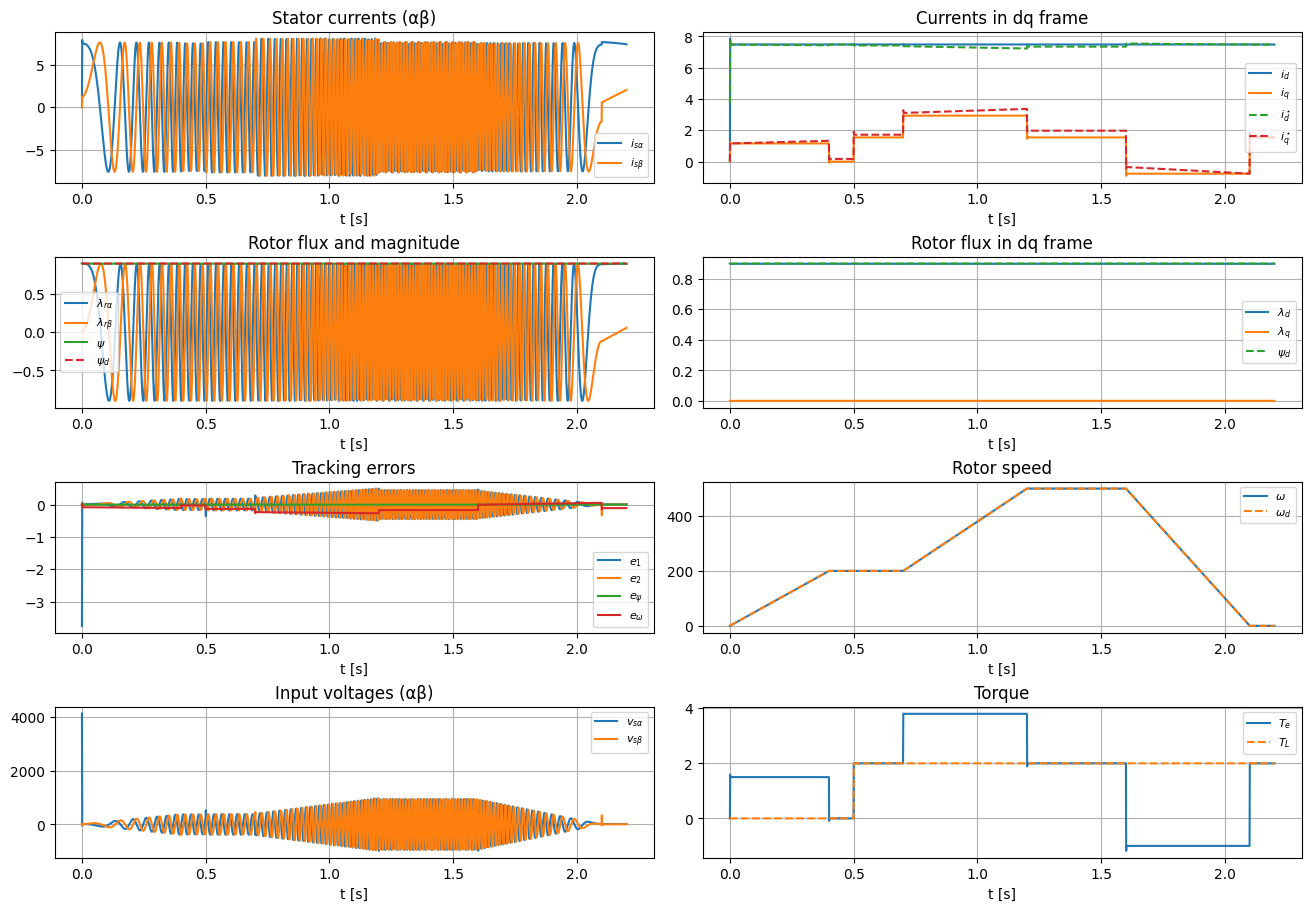

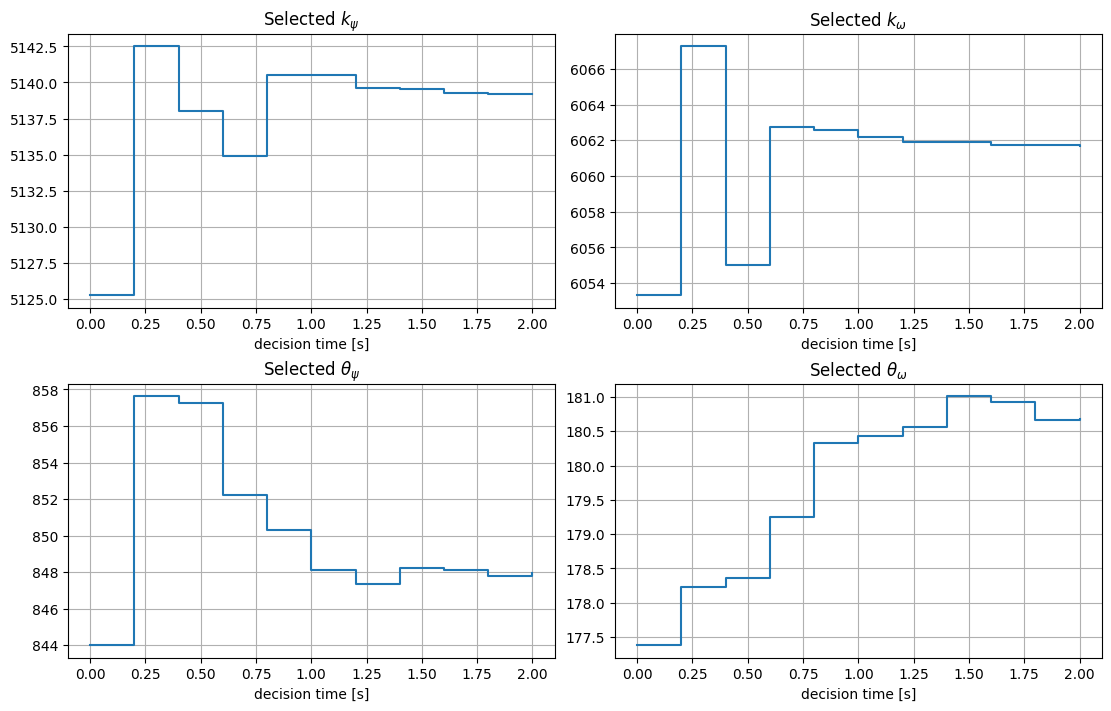

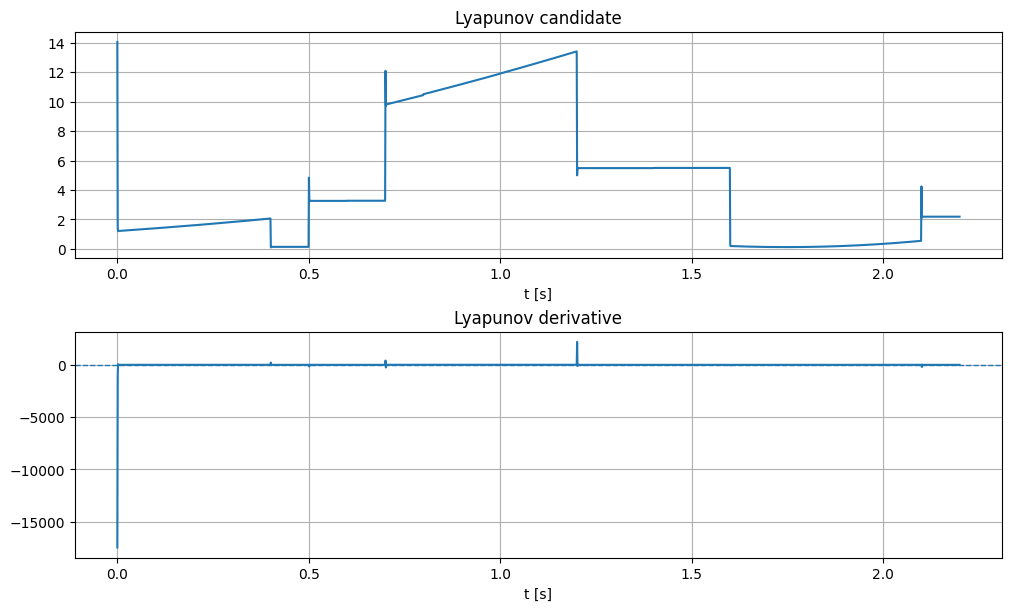


Final state at t = 2.2000s
  i_sα = 7.369839e+00
  i_sβ = 2.026928e+00
  λ_rα = 8.963771e-01
  λ_rβ = 5.807491e-02
  ω    = -1.099672e-01

Final tracking error norm:
  ||e|| = 1.103556e-01

Final parameter ranges after last BH:
  k_psi: [5138.568, 5139.204]
  k_w: [6061.587, 6061.678]
  theta_psi: [847.795, 847.963]
  theta_w: [180.674, 180.930]

Selected online parameters by epoch:
  step 01: solver=qite, nq=12, Hfit=32.001260s, solve=1904.625476s, E=1.246612, J=1.246616, k_psi=5125.271, k_w=6053.313, theta_psi=844.001, theta_w=177.379, s=000010000000
  step 02: solver=qite, nq=12, Hfit=59.608484s, solve=1898.336359s, E=1.091445, J=1.091267, k_psi=5142.502, k_w=6067.270, theta_psi=857.626, theta_w=178.224, s=111111111000
  step 03: solver=qite, nq=12, Hfit=70.985070s, solve=1892.449890s, E=15682.729940, J=15681.379549, k_psi=5138.053, k_w=6055.001, theta_psi=857.241, theta_w=178.357, s=100000111000
  step 04: solver=qite, nq=12, Hfit=75.130590s, solve=1919.480563s, E=357155.953216, J

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

from qiskit.quantum_info import SparsePauliOp, Statevector
from qiskit.primitives import Estimator
from qiskit.circuit.library import EfficientSU2
from qiskit_algorithms import VarQITE
from qiskit_algorithms.time_evolvers import TimeEvolutionProblem
from qiskit_algorithms.time_evolvers.variational import ImaginaryMcLachlanPrinciple
import time
from itertools import product


# ============================================================
# GLOBAL CONFIGURATION
# ============================================================

VERBOSE = False

# ============================================================
# IM DRIVE BASE DATA
# ============================================================

# ---- 3-phase supply settings (used only when mode="threephase") ----
V_phase_rms = 80.0
f_e = 60.0
phase_offset = 0.0

# ---- Motor base parameters ----
L_s = 0.25
L_r = 0.25
p_p = 2
J = 0.003

# ---- Rated parameters used INSIDE controller (fixed model) ----
R_s_ctl = 2.3
R_r_ctl = 2.5
L_m_ctl = 0.24

# ---- Actual plant parameters (mismatch scenario) ----
T_ref = 25.0
alpha_Cu = 0.00393

R_s_ref = 2.3
R_r_ref = 2.5

T_C = 25.0
R_s = R_s_ref * (1.0 + alpha_Cu * (T_C - T_ref))
R_r = R_r_ref * (1.0 + alpha_Cu * (T_C - T_ref))

Lm_nom = 0.24
sat_case = "vstrong"   # "none", "mild", "strong"

if sat_case == "none":
    L_m = Lm_nom
elif sat_case == "mild":
    L_m = 0.90 * Lm_nom
elif sat_case == "strong":
    L_m = 0.75 * Lm_nom
elif sat_case == "vstrong":
    L_m = 0.5 * Lm_nom   # 50% drop
else:
    raise ValueError("Unknown sat_case")

print(f"[PLANT] Using T={T_C}°C: R_s={R_s:.4f}, R_r={R_r:.4f}")
print(f"[PLANT] Saturation case={sat_case}: L_m={L_m:.4f}")
print(f"[CTRL ] Rated params: R_s={R_s_ctl:.4f}, R_r={R_r_ctl:.4f}, L_m={L_m_ctl:.4f}")

# ---- Initial condition: x = [i_sα, i_sβ, λ_rα, λ_rβ, ω] ----
psi_const = 0.9
X0_GLOBAL = np.array([0.0, 0.0, psi_const, 0.0, 0.0], dtype=float)

psi_floor = 1e-3
np.random.seed(0)
# ============================================================
# ONLINE FRAMEWORK SETTINGS
# ============================================================

# Parameters to optimize online:
# p = [k_psi, k_w, theta_psi, theta_w]
PARAM_NAMES = ["k_psi", "k_w", "theta_psi", "theta_w"]

# Search box
P_MIN_GLOBAL = np.array([1.0,   1.0,   0.1,  0.1], dtype=float)
P_MAX_GLOBAL = np.array([10000.0, 10000.0, 2000.0, 2000.0], dtype=float)

# Stage 1: Black Hole
BH_POP_SIZE = 20
BH_MAX_ITERS = 100
BH_FREEZE_WIDTH = 25.0

# Online decision loop
T_TOTAL = 2.2
DT_DECISION = 0.2

# Horizon cost
T_HORIZON_COST = 0.10
N_TIME_COST = 120

# Cost weights
W_EPSI = 2.0
W_EW   = 10.0
W_EI   = 10.0
W_U    = 1e-4
W_LYAP = 1.0

QUBO_SOLVER = "qite"     # "qite", "bruteforce", "classic"
CLASSIC_SOLVER = "sa"    # for now: "sa" = simulated annealing style local search

# QITE
QITE_TAU = 2.0
QITE_STEPS = 60
QITE_REPS = 2
QITE_SEED_BASE = 42

# Classical local-search settings
CLASSIC_NUM_RESTARTS = 20
CLASSIC_MAX_FLIPS = 200
CLASSIC_SEED_BASE = 123

# Hamiltonian fit sampling
TRAIN_SAMPLE_FACTOR = 4
MIN_TRAIN_SAMPLES = 64
TOP_K_CANDIDATES = 32

# Bit allocation
BIT_WIDTH_THRESHOLDS = [5.0, 20.0]
BIT_ALLOCATION = [2, 3, 4]
MAX_BITS_PER_PARAM = 4

# ============================================================
# REFERENCE / LOAD SETTINGS
# ============================================================

mode = "controller"   # "controller" or "threephase"

# ---- Speed reference ----
w_type = "profile"  # "step","ramp","sine","profile","custom"

w_step = 200.0
w_ramp_t0 = 0.1
w_ramp_t1 = 0.8
w_ramp_slope = 250.0

w_sine_amp = 50.0
w_sine_bias = 150.0
w_sine_freq_hz = 1.0

w_profile = (
    (0.0, 0.4, 0.0, 200.0),
    (0.4, 0.7, 200.0, 200.0),
    (0.7, 1.2, 200.0, 500.0),
    (1.2, 1.6, 500.0, 500.0),
    (1.6, 2.1, 500.0, 0.0),
)

def w_custom(t: float):
    w = 100.0 + 50.0*np.sin(2*np.pi*0.5*t)
    dw = 50.0*(2*np.pi*0.5)*np.cos(2*np.pi*0.5*t)
    ddw = -50.0*(2*np.pi*0.5)**2*np.sin(2*np.pi*0.5*t)
    return w, dw, ddw

# ---- Flux reference ----
psi_type = "constant"  # "constant","step","ramp","sine","custom"
psi_step_t0 = 0.1
psi_step = 0.9

psi_ramp_t0 = 0.1
psi_ramp_t1 = 0.8
psi_ramp_slope = 0.2

psi_sine_amp = 0.1
psi_sine_bias = 0.8
psi_sine_freq_hz = 0.5

def psi_custom(t: float):
    psi = 0.9
    return psi, 0.0, 0.0

# ---- Load torque ----
TL_type = "step"  # "constant","step","sine","custom"
TL_const = 1.0

TL_step_t0 = 0.5
TL_step = 2.0

TL_sine_amp = 0.5
TL_sine_bias = 1.0
TL_sine_freq_hz = 1.0

def TL_custom(t: float):
    TL = 1.0
    return TL, 0.0

# ============================================================
# MOTOR COEFFICIENTS
# ============================================================

def motor_coeffs(Rs, Rr, Lm, Ls, Lr, p_p, J):
    L_sigma = Ls * (1.0 - (Lm**2) / (Ls * Lr))

    a_s = Rs / L_sigma + (Rr * Lm**2) / (Lr**2 * L_sigma)
    b_s = (Rr * Lm) / (Lr**2 * L_sigma)
    c_s = Lm / (L_sigma * Lr)

    alpha = (Rr * Lm) / Lr
    beta  = - Rr / Lr
    gamma = (3.0/2.0) * (p_p / J) * (Lm / Lr)

    return L_sigma, a_s, b_s, c_s, alpha, beta, gamma

# Plant coefficients
L_sigma_p, a_s_p, b_s_p, c_s_p, alpha_p, beta_p, gamma_p = motor_coeffs(
    R_s, R_r, L_m, L_s, L_r, p_p, J
)

# Controller nominal coefficients
L_sigma_c, a_s_c, b_s_c, c_s_c, alpha_c, beta_c, gamma_c = motor_coeffs(
    R_s_ctl, R_r_ctl, L_m_ctl, L_s, L_r, p_p, J
)

# ============================================================
# REFERENCES / LOAD
# ============================================================

def ref_step_fn(t: float, t_sw: float, value: float, bias: float = 0.0):
    r = bias + (value if t >= t_sw else 0.0)
    return r, 0.0, 0.0

def ref_ramp_fn(t: float, t0: float, t1: float, slope: float, bias: float = 0.0):
    if t < t0:
        return bias, 0.0, 0.0
    if t < t1:
        r = bias + slope*(t - t0)
        return r, slope, 0.0
    r = bias + slope*(t1 - t0)
    return r, 0.0, 0.0

def ref_sine_fn(t: float, amp: float, bias: float, freq_hz: float):
    w = 2.0*np.pi*freq_hz
    r = bias + amp*np.sin(w*t)
    dr = amp*w*np.cos(w*t)
    ddr = -amp*(w**2)*np.sin(w*t)
    return r, dr, ddr

def ref_piecewise_linear_fn(t: float, segments):
    t0_first, t1_first, y0_first, y1_first = segments[0]
    if t <= t0_first:
        return y0_first, 0.0, 0.0

    for (t0_, t1_, y0_, y1_) in segments:
        if t0_ <= t <= t1_:
            if abs(t1_ - t0_) < 1e-12:
                return y1_, 0.0, 0.0
            slope = (y1_ - y0_) / (t1_ - t0_)
            y = y0_ + slope*(t - t0_)
            return y, slope, 0.0

    return segments[-1][3], 0.0, 0.0

def speed_reference(t: float):
    if w_type == "step":
        return ref_step_fn(t, 0.0, w_step, 0.0)
    if w_type == "ramp":
        return ref_ramp_fn(t, w_ramp_t0, w_ramp_t1, w_ramp_slope, 0.0)
    if w_type == "sine":
        return ref_sine_fn(t, w_sine_amp, w_sine_bias, w_sine_freq_hz)
    if w_type == "profile":
        return ref_piecewise_linear_fn(t, w_profile)
    if w_type == "custom":
        return w_custom(t)
    raise ValueError(f"Unknown w_type: {w_type}")

def flux_reference(t: float):
    if psi_type == "constant":
        return psi_const, 0.0, 0.0
    if psi_type == "step":
        return ref_step_fn(t, psi_step_t0, psi_step, 0.0)
    if psi_type == "ramp":
        return ref_ramp_fn(t, psi_ramp_t0, psi_ramp_t1, psi_ramp_slope, 0.0)
    if psi_type == "sine":
        return ref_sine_fn(t, psi_sine_amp, psi_sine_bias, psi_sine_freq_hz)
    if psi_type == "custom":
        return psi_custom(t)
    raise ValueError(f"Unknown psi_type: {psi_type}")

def load_torque(t: float):
    if TL_type == "constant":
        return TL_const, 0.0
    if TL_type == "step":
        TL = TL_step if t >= TL_step_t0 else 0.0
        return TL, 0.0
    if TL_type == "sine":
        w_ = 2.0*np.pi*TL_sine_freq_hz
        TL = TL_sine_bias + TL_sine_amp*np.sin(w_*t)
        dTL = TL_sine_amp*w_*np.cos(w_*t)
        return TL, dTL
    if TL_type == "custom":
        return TL_custom(t)
    raise ValueError(f"Unknown TL_type: {TL_type}")

def three_phase_voltages(t: float, V_phase_rms: float, f_e: float, phase_offset: float = 0.0):
    w_ = 2.0 * np.pi * f_e
    Vp = np.sqrt(2.0) * V_phase_rms
    va = Vp * np.sin(w_*t + phase_offset)
    vb = Vp * np.sin(w_*t + phase_offset - 2.0*np.pi/3.0)
    vc = Vp * np.sin(w_*t + phase_offset + 2.0*np.pi/3.0)
    return va, vb, vc

def abc_to_alphabeta(va: float, vb: float, vc: float):
    v_alpha = (2.0/3.0) * (va - 0.5*vb - 0.5*vc)
    v_beta  = (2.0/3.0) * (np.sqrt(3.0)/2.0) * (vb - vc)
    return v_alpha, v_beta

def supply_u_alphabeta(t: float):
    va, vb, vc = three_phase_voltages(t, V_phase_rms, f_e, phase_offset)
    return abc_to_alphabeta(va, vb, vc)

def evaluate_true_cost_from_bitstring_im(bitstr, x0, t_start_abs, p_min, p_max, bits_per_param):
    k_psi, k_w, theta_psi, theta_w = decode_bitstring_to_params(
        bitstr, p_min, p_max, bits_per_param
    )
    J = simulate_horizon_cost_im(
        x0, k_psi, k_w, theta_psi, theta_w,
        t_start_abs=t_start_abs
    )
    return J

def brute_force_select_best_bitstring_on_H(H, num_qubits):
    best_s = None
    best_E = float("inf")

    for bits in product("01", repeat=num_qubits):
        s = "".join(bits)
        E = diagonal_hamiltonian_energy_of_bitstring(H, s)
        if E < best_E:
            best_s = s
            best_E = E

    return best_s, best_E

def random_bitstring(n, rng):
    return "".join(rng.choice(["0", "1"], size=n))

def flip_bit(s, idx):
    return s[:idx] + ("1" if s[idx] == "0" else "0") + s[idx+1:]

def classical_local_search_select_best_bitstring_on_H(
    H, num_qubits,
    num_restarts=CLASSIC_NUM_RESTARTS,
    max_flips=CLASSIC_MAX_FLIPS,
    seed=0
):
    rng = np.random.default_rng(seed)

    best_global_s = None
    best_global_E = float("inf")

    for _ in range(num_restarts):
        s = random_bitstring(num_qubits, rng)
        E = diagonal_hamiltonian_energy_of_bitstring(H, s)

        improved = True
        n_iter = 0

        while improved and n_iter < max_flips:
            improved = False
            n_iter += 1

            best_neighbor_s = s
            best_neighbor_E = E

            for j in range(num_qubits):
                s_try = flip_bit(s, j)
                E_try = diagonal_hamiltonian_energy_of_bitstring(H, s_try)
                if E_try < best_neighbor_E:
                    best_neighbor_s = s_try
                    best_neighbor_E = E_try

            if best_neighbor_E < E:
                s = best_neighbor_s
                E = best_neighbor_E
                improved = True

        if E < best_global_E:
            best_global_s = s
            best_global_E = E

    return best_global_s, best_global_E

    
# ============================================================
# DQ FRAME
# ============================================================

Jmat = np.array([[0.0, -1.0],
                 [1.0,  0.0]])

def dq_from_state(x: np.ndarray):
    x1, x2, x3, x4, _w = x
    lam = np.array([x3, x4], dtype=float)
    psi = float(np.sqrt(x3*x3 + x4*x4))
    psi = max(psi, 1e-8)

    e_d = lam / psi
    e_q = Jmat @ e_d

    i_s = np.array([x1, x2], dtype=float)
    i_d = float(e_d @ i_s)
    i_q = float(e_q @ i_s)

    lam_d = float(e_d @ lam)
    lam_q = float(e_q @ lam)

    return psi, e_d, e_q, i_d, i_q, lam_d, lam_q


def solve_qubo_im(
    solver_name,
    H,
    num_qubits,
    x0, t_start_abs,
    p_min, p_max, bits_per_param,
    seed=0
):
    t0 = time.perf_counter()

    if solver_name == "qite":
        best_s, best_E = qite_select_best_bitstring_on_H(
            H, x0, t_start_abs,
            p_min, p_max, bits_per_param,
            tau=QITE_TAU,
            steps=QITE_STEPS,
            reps=QITE_REPS,
            seed=seed
        )

    elif solver_name == "bruteforce":
        best_s, best_E = brute_force_select_best_bitstring_on_H(H, num_qubits)

    elif solver_name == "classic":
        best_s, best_E = classical_local_search_select_best_bitstring_on_H(
            H, num_qubits,
            num_restarts=CLASSIC_NUM_RESTARTS,
            max_flips=CLASSIC_MAX_FLIPS,
            seed=seed
        )

    else:
        raise ValueError(f"Unknown QUBO solver: {solver_name}")

    t1 = time.perf_counter()

    best_J = evaluate_true_cost_from_bitstring_im(
        best_s, x0, t_start_abs, p_min, p_max, bits_per_param
    )

    solver_meta = {
        "solver": solver_name,
        "solve_time_sec": t1 - t0,
        "best_energy": best_E,
    }

    return best_s, best_J, solver_meta
    
# ============================================================
# IM APPLICATION-SPECIFIC SIGNALS
# ============================================================

def im_controller_and_errors(t: float, x: np.ndarray,
                             k_psi: float, k_w: float,
                             theta_psi: float, theta_w: float):
    """
    Compute controller signals, tracking errors, Lyapunov quantities,
    and plant RHS for the induction motor closed loop.
    """
    x1, x2, x3, x4, w = x

    # references
    w_d, dw_d, ddw_d = speed_reference(t)
    psi_d, dpsi_d, ddpsi_d = flux_reference(t)

    # load
    TL, dTL = load_torque(t)

    # dq variables
    psi, e_d, e_q, i_d, i_q, lam_d, lam_q = dq_from_state(x)

    # PLANT rotor flux derivatives
    dx3 = alpha_p*x1 + beta_p*x3 - w*x4
    dx4 = alpha_p*x2 + beta_p*x4 + w*x3
    lam = np.array([x3, x4], dtype=float)
    dlam = np.array([dx3, dx4], dtype=float)

    # PLANT scalar identities
    dpsi = alpha_p*i_d + beta_p*psi
    dw = gamma_p*psi*i_q - (1.0/J)*TL

    # outer errors
    e_psi = psi - psi_d
    e_w = w - w_d

    # controller-side virtual controls
    i_d_star = (dpsi_d - beta_c*psi - k_psi*e_psi) / alpha_c

    psi_eff = max(psi, psi_floor)
    num = (dw_d + (1.0/J)*TL - k_w*e_w)
    i_q_star = num / (gamma_c * psi_eff)

    # derivatives of virtual controls
    di_d_star = (ddpsi_d - beta_c*dpsi - k_psi*(dpsi - dpsi_d)) / alpha_c

    de_w = dw - dw_d
    dnum = ddw_d + (1.0/J)*dTL - k_w*de_w
    di_q_star = (dnum*psi_eff - num*dpsi) / (gamma_c*(psi_eff**2))

    # dq basis derivatives
    de_d = (dlam / psi_eff) - lam * (dpsi / (psi_eff**2))
    de_q = Jmat @ de_d

    # desired current vector
    i_s_d = i_d_star*e_d + i_q_star*e_q
    di_s_d = di_d_star*e_d + i_d_star*de_d + di_q_star*e_q + i_q_star*de_q

    x1d, x2d = float(i_s_d[0]), float(i_s_d[1])
    dx1d, dx2d = float(di_s_d[0]), float(di_s_d[1])

    # inner current tracking errors
    e1 = x1 - x1d
    e2 = x2 - x2d

    # choose inner gains from k_psi, as in your original code
    k1 = 10.0 * k_psi
    k2 = 10.0 * k_psi

    # controller voltages
    if mode == "controller":
        u1 = L_sigma_c * (dx1d + a_s_c*x1 - b_s_c*x3 - c_s_c*w*x4 - k1*e1)
        u2 = L_sigma_c * (dx2d + a_s_c*x2 - b_s_c*x4 + c_s_c*w*x3 - k2*e2)
    elif mode == "threephase":
        u1, u2 = supply_u_alphabeta(t)
    else:
        raise ValueError(f"Unknown mode: {mode}")

    # plant dynamics
    dx1 = -a_s_p*x1 + b_s_p*x3 + c_s_p*w*x4 + (1.0/L_sigma_p)*u1
    dx2 = -a_s_p*x2 + b_s_p*x4 - c_s_p*w*x3 + (1.0/L_sigma_p)*u2
    dx5 = dw

    dxdt = np.array([dx1, dx2, dx3, dx4, dx5], dtype=float)

    # For Lyapunov derivative:
    # e1_dot = x1_dot - x1d_dot
    # e2_dot = x2_dot - x2d_dot
    de1 = dx1 - dx1d
    de2 = dx2 - dx2d
    depsi = dpsi - dpsi_d
    dew = dw - dw_d

    V = theta_psi*(e_psi**2) + theta_w*(e_w**2) + e1**2 + e2**2
    dVdt = (
        2.0*theta_psi*e_psi*depsi
        + 2.0*theta_w*e_w*dew
        + 2.0*e1*de1
        + 2.0*e2*de2
    )

    return {
        "dxdt": dxdt,
        "u": np.array([u1, u2], dtype=float),
        "e_psi": e_psi,
        "e_w": e_w,
        "e1": e1,
        "e2": e2,
        "V": V,
        "dVdt": dVdt,
        "psi": psi,
        "w": w,
        "psi_d": psi_d,
        "w_d": w_d,
        "TL": TL,
        "Te": J * gamma_p * psi * i_q,
        "id": i_d,
        "iq": i_q,
        "id_star": i_d_star,
        "iq_star": i_q_star,
        "lam_d": lam_d,
        "lam_q": lam_q,
    }

def closed_loop_dynamics_im(t, x, k_psi, k_w, theta_psi, theta_w):
    return im_controller_and_errors(t, x, k_psi, k_w, theta_psi, theta_w)["dxdt"]

def control_law_im(t, x, k_psi, k_w, theta_psi, theta_w):
    return im_controller_and_errors(t, x, k_psi, k_w, theta_psi, theta_w)["u"]

def lyapunov_V_im(t, x, k_psi, k_w, theta_psi, theta_w):
    return im_controller_and_errors(t, x, k_psi, k_w, theta_psi, theta_w)["V"]

def lyapunov_dVdt_im(t, x, k_psi, k_w, theta_psi, theta_w):
    return im_controller_and_errors(t, x, k_psi, k_w, theta_psi, theta_w)["dVdt"]

# ============================================================
# SHORT-HORIZON COST FOR IM DRIVE
# ============================================================

def simulate_horizon_cost_im(x0,
                             k_psi, k_w, theta_psi, theta_w,
                             t_start_abs,
                             t_horizon=T_HORIZON_COST,
                             n_time=N_TIME_COST,
                             w_epsi=W_EPSI,
                             w_ew=W_EW,
                             w_ei=W_EI,
                             w_u=W_U,
                             w_lyap=W_LYAP):
    """
    Short-horizon IM tracking + Lyapunov-aware cost.
    Absolute time matters because references/load are time-varying.
    """
    t_span = (t_start_abs, t_start_abs + t_horizon)
    t_eval = np.linspace(t_span[0], t_span[1], n_time)

    def dyn(t, x):
        return closed_loop_dynamics_im(t, x, k_psi, k_w, theta_psi, theta_w)

    sol = solve_ivp(
        dyn, t_span, x0, t_eval=t_eval,
        method="RK45", rtol=1e-6, atol=1e-8
    )

    if not sol.success:
        return 1e10

    t = sol.t
    X = sol.y

    if np.any(np.isnan(X)) or np.any(np.isinf(X)):
        return 1e10

    if np.any(np.abs(X) > 1e5):
        return 1e10

    epsi_sq = np.zeros_like(t)
    ew_sq   = np.zeros_like(t)
    ei_sq   = np.zeros_like(t)
    u_sq    = np.zeros_like(t)
    dV_pen  = np.zeros_like(t)

    for idx, tt in enumerate(t):
        sig = im_controller_and_errors(tt, X[:, idx], k_psi, k_w, theta_psi, theta_w)
        epsi_sq[idx] = sig["e_psi"]**2
        ew_sq[idx]   = sig["e_w"]**2
        ei_sq[idx]   = sig["e1"]**2 + sig["e2"]**2
        u_sq[idx]    = sig["u"][0]**2 + sig["u"][1]**2
        dV_pen[idx]  = max(0.0, sig["dVdt"])**2

    integrand = (
        w_epsi * epsi_sq
        + w_ew * ew_sq
        + w_ei * ei_sq
        + w_u * u_sq
        + w_lyap * dV_pen
    )

    J_total = float(np.trapz(integrand, t))
    return J_total

# ============================================================
# STAGE 1: BLACK HOLE RANGE CALIBRATION
# ============================================================

def bh_initialize_population(p_min_init, p_max_init):
    n_params = len(PARAM_NAMES)
    stars = np.random.uniform(
        low=p_min_init,
        high=p_max_init,
        size=(BH_POP_SIZE, n_params)
    )
    return stars

def bh_evaluate_population(stars, x0, t_start_abs):
    costs = np.zeros(len(stars))
    for i, p in enumerate(stars):
        k_psi, k_w, theta_psi, theta_w = p
        costs[i] = simulate_horizon_cost_im(
            x0, k_psi, k_w, theta_psi, theta_w,
            t_start_abs=t_start_abs
        )
    return costs

def bh_range_calibration(p_min_init, p_max_init, x0, t_start_abs):

    n_params = len(PARAM_NAMES)
    stars = bh_initialize_population(p_min_init, p_max_init)
    active = np.ones(n_params, dtype=bool)
    p_min = p_min_init.copy()
    p_max = p_max_init.copy()

    for it in range(BH_MAX_ITERS):
        costs = bh_evaluate_population(stars, x0, t_start_abs)
        best_idx = np.argmin(costs)
        black_hole = stars[best_idx].copy()
        best_cost = costs[best_idx]

        if VERBOSE:
            print(f"[BH] Iter {it+1}/{BH_MAX_ITERS}, best_cost={best_cost:.4e}")

        for i in range(BH_POP_SIZE):
            if i == best_idx:
                continue
            rand_vec = np.random.rand(np.sum(active))
            stars[i, active] = stars[i, active] + rand_vec * (black_hole[active] - stars[i, active])

        for j in range(n_params):
            stars[:, j] = np.clip(stars[:, j], p_min[j], p_max[j])

        for j in range(n_params):
            if not active[j]:
                continue
            cur_min = np.min(stars[:, j])
            cur_max = np.max(stars[:, j])
            p_min[j] = max(cur_min, P_MIN_GLOBAL[j])
            p_max[j] = min(cur_max, P_MAX_GLOBAL[j])
            width = p_max[j] - p_min[j]

            if width <= BH_FREEZE_WIDTH:
                active[j] = False
                if VERBOSE:
                    print(f"[BH] Param {PARAM_NAMES[j]} frozen with range [{p_min[j]:.3f}, {p_max[j]:.3f}]")

        if not np.any(active):
            if VERBOSE:
                print("[BH] All parameters frozen.")
            break

    if VERBOSE:
        print("[BH] Final ranges:")
        for name, mn, mx in zip(PARAM_NAMES, p_min, p_max):
            print(f"   {name}: [{mn:.3f}, {mx:.3f}], width={mx-mn:.3f}")

    return p_min, p_max

# ============================================================
# BIT ALLOCATION / PARAMETER ENCODING
# ============================================================

def choose_bits_for_width(width):
    return 3

def allocate_bits_for_parameters(p_min, p_max):
    widths = p_max - p_min
    bits_per_param = [choose_bits_for_width(w) for w in widths]
    num_qubits = int(np.sum(bits_per_param))

    if VERBOSE:
        print("[Bits] Allocation:")
        for name, w, b in zip(PARAM_NAMES, widths, bits_per_param):
            print(f"   {name}: width={w:.3f}, bits={b}")
        print(f"   Total qubits = {num_qubits}")
    return bits_per_param, num_qubits

def decode_bitstring_to_params(bitstr, p_min, p_max, bits_per_param):
    assert len(bitstr) == int(np.sum(bits_per_param))
    p_min = np.asarray(p_min)
    p_max = np.asarray(p_max)

    params = []
    idx = 0
    for i, n_bits in enumerate(bits_per_param):
        bits_i = bitstr[idx: idx+n_bits]
        idx += n_bits
        v = int(bits_i, 2)
        levels = 2**n_bits - 1
        if levels <= 0:
            p_val = p_min[i]
        else:
            p_val = p_min[i] + (p_max[i] - p_min[i]) * (v / levels)
        params.append(p_val)

    return params

# ============================================================
# DIAGONAL PAULI BASIS / HAMILTONIAN FIT
# ============================================================

def build_diagonal_pauli_basis(num_qubits):
    n = num_qubits
    paulis = []

    paulis.append("I" * n)

    for i in range(n):
        s = ["I"] * n
        s[i] = "Z"
        paulis.append("".join(s))

    for i in range(n):
        for j in range(i + 1, n):
            s = ["I"] * n
            s[i] = "Z"
            s[j] = "Z"
            paulis.append("".join(s))

    return paulis

def eigenvalue_of_pauli_on_bitstring(pauli_label, bitstr):
    n = len(bitstr)
    assert len(pauli_label) == n
    bits = [int(b) for b in bitstr]
    eig = 1.0
    for j in range(n):
        p = pauli_label[n - 1 - j]
        if p == 'Z':
            eig *= (1.0 if bits[-1 - j] == 0 else -1.0)
        elif p == 'I':
            continue
        else:
            raise ValueError("Non-diagonal Pauli encountered.")
    return eig

def sample_bitstrings(num_qubits, num_samples):
    bitstrings = set()
    while len(bitstrings) < num_samples:
        s = ''.join(np.random.choice(['0', '1'], size=num_qubits))
        bitstrings.add(s)
    return list(bitstrings)

def fit_diagonal_hamiltonian_sampled_im(x0, t_start_abs, p_min, p_max, bits_per_param,
                                        paulis, num_qubits):
    n_basis = len(paulis)
    num_samples = max(TRAIN_SAMPLE_FACTOR * n_basis, MIN_TRAIN_SAMPLES)

    if VERBOSE:
        print(f"[H-fit] num_qubits={num_qubits}, n_basis={n_basis}, num_samples={num_samples}")

    sampled_bitstrings = sample_bitstrings(num_qubits, num_samples)

    M = np.zeros((num_samples, n_basis), dtype=float)
    J_vec = np.zeros(num_samples, dtype=float)

    for idx, s in enumerate(sampled_bitstrings):
        k_psi, k_w, theta_psi, theta_w = decode_bitstring_to_params(
            s, p_min, p_max, bits_per_param
        )
        J = simulate_horizon_cost_im(
            x0, k_psi, k_w, theta_psi, theta_w,
            t_start_abs=t_start_abs
        )
        J_vec[idx] = J

        for k, P in enumerate(paulis):
            M[idx, k] = eigenvalue_of_pauli_on_bitstring(P, s)

    h, *_ = np.linalg.lstsq(M, J_vec, rcond=None)

    if VERBOSE:
        print("[H-fit] first few coefficients:")
        for coef, P in list(zip(h, paulis))[:10]:
            print(f"   {P}: {coef:.6f}")

    H = SparsePauliOp.from_list(list(zip(paulis, h)))
    return H

# ============================================================
# QITE SELECTION
# ============================================================

def qite_select_best_bitstring_on_H(
    H, x0, t_start_abs, p_min, p_max, bits_per_param,
    tau=QITE_TAU,
    steps=QITE_STEPS,
    reps=QITE_REPS,
    seed=0
):
    np.random.seed(seed)
    num_qubits = int(np.sum(bits_per_param))

    ansatz = EfficientSU2(num_qubits, reps=reps, entanglement='linear')
    n_params = ansatz.num_parameters

    init_params = 0.02 * np.random.randn(n_params)

    est = Estimator()
    principle = ImaginaryMcLachlanPrinciple()
    varqite = VarQITE(
        ansatz=ansatz,
        initial_parameters=init_params,
        variational_principle=principle,
        estimator=est,
        num_timesteps=steps,
    )

    problem = TimeEvolutionProblem(hamiltonian=H, time=tau)
    result = varqite.evolve(problem)

    final_circ = result.evolved_state
    sv = Statevector.from_instruction(final_circ)
    probs = sv.probabilities_dict()

    sorted_items = sorted(probs.items(), key=lambda kv: kv[1], reverse=True)
    candidates = sorted_items[:min(TOP_K_CANDIDATES, len(sorted_items))]

    best_s = None
    best_E = float("inf")

    for s, _p_prob in candidates:
        E = diagonal_hamiltonian_energy_of_bitstring(H, s)
        if E < best_E:
            best_s = s
            best_E = E

    return best_s, best_E
    
# ============================================================
# FULL 2-STAGE ONLINE QUANTUM FRAMEWORK FOR IM DRIVE
# ============================================================

def diagonal_hamiltonian_energy_of_bitstring(H, bitstr):
    energy = 0.0
    labels = H.paulis.to_labels()
    coeffs = np.real(H.coeffs)

    for label, coeff in zip(labels, coeffs):
        energy += coeff * eigenvalue_of_pauli_on_bitstring(label, bitstr)

    return float(energy)

def dynamic_quantum_lyapunov_synthesis_im():
    print("=== Dynamic Quantum Lyapunov Synthesis for IM Drive ===")

    # Current ranges
    p_min_curr = P_MIN_GLOBAL.copy()
    p_max_curr = P_MAX_GLOBAL.copy()

    # Current state
    x_current = X0_GLOBAL.copy()

    # Global storage
    t_global = [0.0]
    X_global = [x_current.copy()]
    U_global = [np.array([0.0, 0.0], dtype=float)]

    selected_hist = {
        "k_psi": [],
        "k_w": [],
        "theta_psi": [],
        "theta_w": [],
        "cost": [],
        "energy": [],
        "bitstring": [],
        "solver": [],
        "solve_time_sec": [],
        "hamiltonian_fit_time_sec": [],
        "num_qubits": [],
    }

    max_steps = int(np.ceil(T_TOTAL / DT_DECISION))

    for k_step in range(max_steps):
        t_start = t_global[-1]
        if t_start >= T_TOTAL - 1e-12:
            break

        print(f"\n=== Decision step {k_step+1}/{max_steps} at t={t_start:.4f}s ===")

        # ---------------------------------------------------
        # Stage 1: BH range calibration
        # ---------------------------------------------------
        p_min_step, p_max_step = bh_range_calibration(
            p_min_curr, p_max_curr, x_current, t_start_abs=t_start
        )
        p_min_curr = p_min_step
        p_max_curr = p_max_step

        print("   Updated parameter ranges after BH:")
        for name, mn, mx in zip(PARAM_NAMES, p_min_curr, p_max_curr):
            print(f"      {name}: [{mn:.3f}, {mx:.3f}] (width={mx-mn:.3f})")

        bits_per_param, num_qubits = allocate_bits_for_parameters(p_min_curr, p_max_curr)
        paulis = build_diagonal_pauli_basis(num_qubits)

        # ---------------------------------------------------
        # Stage 2: Hamiltonian fit + QITE
        # ---------------------------------------------------

        t_fit0 = time.perf_counter()
        H = fit_diagonal_hamiltonian_sampled_im(
            x_current, t_start,
            p_min_curr, p_max_curr, bits_per_param,
            paulis, num_qubits
        )
        t_fit1 = time.perf_counter()
        hamiltonian_fit_time_sec = t_fit1 - t_fit0

        best_s, best_J, solver_meta = solve_qubo_im(
            solver_name=QUBO_SOLVER,
            H=H,
            num_qubits=num_qubits,
            x0=x_current,
            t_start_abs=t_start,
            p_min=p_min_curr,
            p_max=p_max_curr,
            bits_per_param=bits_per_param,
            seed=QITE_SEED_BASE + k_step
        )

        k_psi, k_w, theta_psi, theta_w = decode_bitstring_to_params(
            best_s, p_min_curr, p_max_curr, bits_per_param
        )

        print(
            f"   Selected params: s={best_s}, "
            f"k_psi={k_psi:.3f}, k_w={k_w:.3f}, "
            f"theta_psi={theta_psi:.3f}, theta_w={theta_w:.3f}, "
            f"E={solver_meta['best_energy']:.6f}, "
            f"J={best_J:.6f}"
        )
        print(
            f"   solver = {solver_meta['solver']}, "
            f"num_qubits = {num_qubits}, "
            f"H-fit time = {hamiltonian_fit_time_sec:.6f} s, "
            f"QUBO solve time = {solver_meta['solve_time_sec']:.6f} s"
        )

        selected_hist["k_psi"].append(k_psi)
        selected_hist["k_w"].append(k_w)
        selected_hist["theta_psi"].append(theta_psi)
        selected_hist["theta_w"].append(theta_w)
        selected_hist["cost"].append(best_J)
        selected_hist["bitstring"].append(best_s)
        selected_hist["solver"].append(solver_meta["solver"])
        selected_hist["solve_time_sec"].append(solver_meta["solve_time_sec"])
        selected_hist["num_qubits"].append(num_qubits)
        selected_hist["energy"].append(solver_meta["best_energy"])
        selected_hist["hamiltonian_fit_time_sec"].append(hamiltonian_fit_time_sec)

        # ---------------------------------------------------
        # Apply selected params over next interval
        # ---------------------------------------------------
        t_end = min(t_start + DT_DECISION, T_TOTAL)
        t_span = (t_start, t_end)
        t_eval = np.linspace(t_start, t_end, 200)

        def dyn_interval(t, x):
            return closed_loop_dynamics_im(t, x, k_psi, k_w, theta_psi, theta_w)

        sol = solve_ivp(
            dyn_interval, t_span, x_current, t_eval=t_eval,
            method="RK45", rtol=1e-6, atol=1e-8
        )

        if not sol.success:
            print("   Integration failed:", sol.message)
            break

        t_local = sol.t
        X_local = sol.y
        U_local = np.zeros((2, len(t_local)))

        # store controls
        for idx, tt in enumerate(t_local):
            U_local[:, idx] = control_law_im(tt, X_local[:, idx], k_psi, k_w, theta_psi, theta_w)

        if k_step == 0 and len(t_global) == 1:
            t_global = list(t_local)
            X_global = [X_local[:, i] for i in range(X_local.shape[1])]
            U_global = [U_local[:, i] for i in range(U_local.shape[1])]
        else:
            t_global.extend(list(t_local[1:]))
            X_global.extend([X_local[:, i] for i in range(1, X_local.shape[1])])
            U_global.extend([U_local[:, i] for i in range(1, U_local.shape[1])])

        x_current = X_local[:, -1].copy()

        sig_end = im_controller_and_errors(t_local[-1], x_current, k_psi, k_w, theta_psi, theta_w)
        track_err = np.sqrt(
            sig_end["e_psi"]**2 + sig_end["e_w"]**2 + sig_end["e1"]**2 + sig_end["e2"]**2
        )

        print(f"   State at end of interval: {x_current}")
        print(f"   Tracking error norm = {track_err:.3e}")


    # Convert outputs
    t_global = np.array(t_global)
    X_global = np.array(X_global).T
    U_global = np.array(U_global).T

    return t_global, X_global, U_global, selected_hist, p_min_curr, p_max_curr

# ============================================================
# POSTPROCESS
# ============================================================

def postprocess_im_trajectories(t, X, U, selected_hist):
    N = len(t)

    u_hist = U.T.copy()
    TL_hist = np.zeros(N)

    w_d_hist = np.zeros(N)
    psi_d_hist = np.zeros(N)
    psi_hist = np.zeros(N)

    e1_hist = np.zeros(N)
    e2_hist = np.zeros(N)
    epsi_hist = np.zeros(N)
    ew_hist = np.zeros(N)

    id_hist = np.zeros(N)
    iq_hist = np.zeros(N)
    id_star_hist = np.zeros(N)
    iq_star_hist = np.zeros(N)

    lamd_hist = np.zeros(N)
    lamq_hist = np.zeros(N)
    Te_hist = np.zeros(N)
    V_hist = np.zeros(N)
    dVdt_hist = np.zeros(N)

    # reconstruct epoch-wise selected parameters
    epoch_times = np.arange(0.0, len(selected_hist["k_psi"]) * DT_DECISION, DT_DECISION)

    def params_at_time(tt):
        idx = min(int(np.floor(tt / DT_DECISION)), len(selected_hist["k_psi"]) - 1)
        return (
            selected_hist["k_psi"][idx],
            selected_hist["k_w"][idx],
            selected_hist["theta_psi"][idx],
            selected_hist["theta_w"][idx],
        )

    for k, tk in enumerate(t):
        x = X[:, k]
        TL, _ = load_torque(tk)
        TL_hist[k] = TL

        w_d, _, _ = speed_reference(tk)
        psi_d, _, _ = flux_reference(tk)
        w_d_hist[k] = w_d
        psi_d_hist[k] = psi_d

        k_psi, k_w, theta_psi, theta_w = params_at_time(tk)

        sig = im_controller_and_errors(tk, x, k_psi, k_w, theta_psi, theta_w)

        psi_hist[k] = sig["psi"]
        epsi_hist[k] = sig["e_psi"]
        ew_hist[k] = sig["e_w"]
        e1_hist[k] = sig["e1"]
        e2_hist[k] = sig["e2"]

        id_hist[k] = sig["id"]
        iq_hist[k] = sig["iq"]
        id_star_hist[k] = sig["id_star"]
        iq_star_hist[k] = sig["iq_star"]

        lamd_hist[k] = sig["lam_d"]
        lamq_hist[k] = sig["lam_q"]

        Te_hist[k] = sig["Te"]
        V_hist[k] = sig["V"]
        dVdt_hist[k] = sig["dVdt"]

    return {
        "u_hist": u_hist,
        "TL_hist": TL_hist,
        "w_d_hist": w_d_hist,
        "psi_d_hist": psi_d_hist,
        "psi_hist": psi_hist,
        "e1_hist": e1_hist,
        "e2_hist": e2_hist,
        "epsi_hist": epsi_hist,
        "ew_hist": ew_hist,
        "id_hist": id_hist,
        "iq_hist": iq_hist,
        "id_star_hist": id_star_hist,
        "iq_star_hist": iq_star_hist,
        "lamd_hist": lamd_hist,
        "lamq_hist": lamq_hist,
        "Te_hist": Te_hist,
        "V_hist": V_hist,
        "dVdt_hist": dVdt_hist,
    }

# ============================================================
# RUN
# ============================================================

if __name__ == "__main__":
    t, X, U, selected_hist, p_min_final, p_max_final = dynamic_quantum_lyapunov_synthesis_im()

    post = postprocess_im_trajectories(t, X, U, selected_hist)

    x1 = X[0, :]
    x2 = X[1, :]
    x3 = X[2, :]
    x4 = X[3, :]
    w  = X[4, :]

    # ========================================================
    # Plot 1: states / references / errors / control / torque
    # ========================================================
    fig, ax = plt.subplots(4, 2, figsize=(13, 9), constrained_layout=True)

    ax[0, 0].plot(t, x1, label=r"$i_{s\alpha}$")
    ax[0, 0].plot(t, x2, label=r"$i_{s\beta}$")
    ax[0, 0].set_title("Stator currents (αβ)")
    ax[0, 0].set_xlabel("t [s]")
    ax[0, 0].grid(True)
    ax[0, 0].legend(fontsize=8)

    ax[0, 1].plot(t, post["id_hist"], label=r"$i_d$")
    ax[0, 1].plot(t, post["iq_hist"], label=r"$i_q$")
    ax[0, 1].plot(t, post["id_star_hist"], "--", label=r"$i_d^\star$")
    ax[0, 1].plot(t, post["iq_star_hist"], "--", label=r"$i_q^\star$")
    ax[0, 1].set_title("Currents in dq frame")
    ax[0, 1].set_xlabel("t [s]")
    ax[0, 1].grid(True)
    ax[0, 1].legend(fontsize=8)

    ax[1, 0].plot(t, x3, label=r"$\lambda_{r\alpha}$")
    ax[1, 0].plot(t, x4, label=r"$\lambda_{r\beta}$")
    ax[1, 0].plot(t, post["psi_hist"], label=r"$\psi$")
    ax[1, 0].plot(t, post["psi_d_hist"], "--", label=r"$\psi_d$")
    ax[1, 0].set_title("Rotor flux and magnitude")
    ax[1, 0].set_xlabel("t [s]")
    ax[1, 0].grid(True)
    ax[1, 0].legend(fontsize=8)

    ax[1, 1].plot(t, post["lamd_hist"], label=r"$\lambda_d$")
    ax[1, 1].plot(t, post["lamq_hist"], label=r"$\lambda_q$")
    ax[1, 1].plot(t, post["psi_d_hist"], "--", label=r"$\psi_d$")
    ax[1, 1].set_title("Rotor flux in dq frame")
    ax[1, 1].set_xlabel("t [s]")
    ax[1, 1].grid(True)
    ax[1, 1].legend(fontsize=8)

    ax[2, 0].plot(t, post["e1_hist"], label=r"$e_1$")
    ax[2, 0].plot(t, post["e2_hist"], label=r"$e_2$")
    ax[2, 0].plot(t, post["epsi_hist"], label=r"$e_\psi$")
    ax[2, 0].plot(t, post["ew_hist"], label=r"$e_\omega$")
    ax[2, 0].set_title("Tracking errors")
    ax[2, 0].set_xlabel("t [s]")
    ax[2, 0].grid(True)
    ax[2, 0].legend(fontsize=8)

    ax[2, 1].plot(t, w, label=r"$\omega$")
    ax[2, 1].plot(t, post["w_d_hist"], "--", label=r"$\omega_d$")
    ax[2, 1].set_title("Rotor speed")
    ax[2, 1].set_xlabel("t [s]")
    ax[2, 1].grid(True)
    ax[2, 1].legend(fontsize=8)

    ax[3, 0].plot(t, post["u_hist"][:, 0], label=r"$v_{s\alpha}$")
    ax[3, 0].plot(t, post["u_hist"][:, 1], label=r"$v_{s\beta}$")
    ax[3, 0].set_title("Input voltages (αβ)")
    ax[3, 0].set_xlabel("t [s]")
    ax[3, 0].grid(True)
    ax[3, 0].legend(fontsize=8)

    ax[3, 1].plot(t, post["Te_hist"], label=r"$T_e$")
    ax[3, 1].plot(t, post["TL_hist"], "--", label=r"$T_L$")
    ax[3, 1].set_title("Torque")
    ax[3, 1].set_xlabel("t [s]")
    ax[3, 1].grid(True)
    ax[3, 1].legend(fontsize=8)

    plt.show()

    # ========================================================
    # Plot 2: online updated parameters
    # ========================================================
    if len(selected_hist["k_psi"]) > 0:
        t_epoch = np.arange(len(selected_hist["k_psi"])) * DT_DECISION

        fig2, ax2 = plt.subplots(2, 2, figsize=(11, 7), constrained_layout=True)

        ax2[0, 0].step(t_epoch, selected_hist["k_psi"], where="post")
        ax2[0, 0].set_title(r"Selected $k_\psi$")
        ax2[0, 0].set_xlabel("decision time [s]")
        ax2[0, 0].grid(True)

        ax2[0, 1].step(t_epoch, selected_hist["k_w"], where="post")
        ax2[0, 1].set_title(r"Selected $k_\omega$")
        ax2[0, 1].set_xlabel("decision time [s]")
        ax2[0, 1].grid(True)

        ax2[1, 0].step(t_epoch, selected_hist["theta_psi"], where="post")
        ax2[1, 0].set_title(r"Selected $\theta_\psi$")
        ax2[1, 0].set_xlabel("decision time [s]")
        ax2[1, 0].grid(True)

        ax2[1, 1].step(t_epoch, selected_hist["theta_w"], where="post")
        ax2[1, 1].set_title(r"Selected $\theta_\omega$")
        ax2[1, 1].set_xlabel("decision time [s]")
        ax2[1, 1].grid(True)

        plt.show()

    # ========================================================
    # Plot 3: Lyapunov candidate and derivative
    # ========================================================
    fig3, ax3 = plt.subplots(2, 1, figsize=(10, 6), constrained_layout=True)

    ax3[0].plot(t, post["V_hist"])
    ax3[0].set_title("Lyapunov candidate")
    ax3[0].set_xlabel("t [s]")
    ax3[0].grid(True)

    ax3[1].plot(t, post["dVdt_hist"])
    ax3[1].axhline(0.0, linestyle="--", linewidth=1)
    ax3[1].set_title("Lyapunov derivative")
    ax3[1].set_xlabel("t [s]")
    ax3[1].grid(True)

    plt.show()

    print("\nFinal state at t = {:.4f}s".format(t[-1]))
    print(f"  i_sα = {X[0, -1]:.6e}")
    print(f"  i_sβ = {X[1, -1]:.6e}")
    print(f"  λ_rα = {X[2, -1]:.6e}")
    print(f"  λ_rβ = {X[3, -1]:.6e}")
    print(f"  ω    = {X[4, -1]:.6e}")

    final_idx = -1
    final_track_err = np.sqrt(
        post["epsi_hist"][final_idx]**2 +
        post["ew_hist"][final_idx]**2 +
        post["e1_hist"][final_idx]**2 +
        post["e2_hist"][final_idx]**2
    )
    print("\nFinal tracking error norm:")
    print(f"  ||e|| = {final_track_err:.6e}")

    print("\nFinal parameter ranges after last BH:")
    for name, mn, mx in zip(PARAM_NAMES, p_min_final, p_max_final):
        print(f"  {name}: [{mn:.3f}, {mx:.3f}]")

    print("\nSelected online parameters by epoch:")
    for k in range(len(selected_hist["k_psi"])):
        print(
            f"  step {k+1:02d}: "
            f"solver={selected_hist['solver'][k]}, "
            f"nq={selected_hist['num_qubits'][k]}, "
            f"Hfit={selected_hist['hamiltonian_fit_time_sec'][k]:.6f}s, "
            f"solve={selected_hist['solve_time_sec'][k]:.6f}s, "
            f"E={selected_hist['energy'][k]:.6f}, "
            f"J={selected_hist['cost'][k]:.6f}, "
            f"k_psi={selected_hist['k_psi'][k]:.3f}, "
            f"k_w={selected_hist['k_w'][k]:.3f}, "
            f"theta_psi={selected_hist['theta_psi'][k]:.3f}, "
            f"theta_w={selected_hist['theta_w'][k]:.3f}, "
            f"s={selected_hist['bitstring'][k]}"
        )
    if len(selected_hist["solve_time_sec"]) > 0:
        print("\nQUBO solve-time summary:")
        print(f"  total = {np.sum(selected_hist['solve_time_sec']):.6f} s")
        print(f"  mean  = {np.mean(selected_hist['solve_time_sec']):.6f} s")
        print(f"  max   = {np.max(selected_hist['solve_time_sec']):.6f} s")

    print("\nPeak |i_sα|, |i_sβ|:", np.max(np.abs(X[0, :])), np.max(np.abs(X[1, :])))
    print("Peak |v_sα|, |v_sβ|:", np.max(np.abs(post["u_hist"][:, 0])), np.max(np.abs(post["u_hist"][:, 1])))